<a href="https://colab.research.google.com/github/farrelrassya/ensemble-methods-machine-learning/blob/main/ch6_newton_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 — Sequential Ensembles: Newton Boosting

This notebook is a unified, end-to-end walkthrough of **Chapter 6** of *Ensemble Methods for Machine Learning* by Gautam Kunapuli. It merges four original section notebooks into a single, executable Colab-friendly document that covers:

- **6.1** Newton's method for minimization — second-order optimization compared to gradient descent
- **6.2** Newton boosting from scratch — combining Newton's descent with boosting via Hessian-weighted residuals
- **6.3** XGBoost as a production framework for Newton boosting
- **6.4** XGBoost in practice — learning-rate tuning and early stopping
- **6.5** Case study — the LETOR document-retrieval task, comparing XGBoost to LightGBM variants

### Why this chapter matters

Chapters 4 and 5 built two boosting families:

- **AdaBoost** assigns *weights* to misclassified examples (chapter 4).
- **Gradient boosting** uses *residuals* — the gradient of the loss (chapter 5).

Newton boosting combines both ideas: it uses **Hessian-weighted residuals**. The first derivative tells us *which direction* to move; the second derivative tells us *how curvy the loss surface is* at each example. Examples sitting in flat regions get bigger updates; examples in highly curved regions get smaller, more conservative updates. This second-order awareness is what makes XGBoost such a competitive framework on tabular data — and why it has dominated Kaggle competitions and production ML systems for years.

Throughout this notebook we link every numerical output to the underlying optimization theory and offer practitioner-level commentary on what the numbers mean for real systems.

## Environment setup

We install XGBoost (used from section 6.3 onward) and import the standard scientific-Python stack. The dataset for section 6.5, **MQ2008 / LETOR**, is downloaded from Microsoft Research Asia and unpacked into a local `data/` directory so that `load_svmlight_file` can read it.

In [ ]:
!pip install "scikit-learn<1.6.0" "xgboost" --upgrade

In [1]:
# Install XGBoost (already on Colab in most images, but ensure version)
!pip install -q xgboost==2.1.3

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as col
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Reproducibility
np.random.seed(42)

### Plotting helpers

The original chapter ships with a `plot_utils.py` module containing two helpers — `plot_2d_data` and `plot_2d_classifier` — that we use repeatedly to visualize 2D classification surfaces. For self-containment, we inline those definitions below.

In [2]:
import matplotlib.cm as cm
import matplotlib.colors as col
import numpy as np

# Plot a 2D classification data set onto the specified axes
def plot_2d_data(ax, X, y, s=20, alpha=0.95, xlabel=None, ylabel=None, title=None, legend=None, colormap='viridis'):
    # Get data set size
    n_examples, n_features = X.shape

    # Check that the data set is 2D
    if n_features != 2:
        raise ValueError('Data set is not 2D!')

    # Check that the lengths of X and y match
    if n_examples != len(y):
        raise ValueError('Length of X is not equal to the length of y!')

    # Get the unique labels and set up marker styles and colors
    unique_labels = np.sort(np.unique(y))
    n_classes = len(unique_labels)

    markers = ['o', 's', '^', 'v', '<', '>', 'p']

    cmap = cm.get_cmap(colormap)
    colors = cmap(np.linspace(0, 0.5, num=n_classes))

    # Set marker sizes
    if isinstance(s, np.ndarray):
        # If its an ndarray, make sure it has the same size as the number of examples
        if len(s) != n_examples:
            raise ValueError('Length of s is not equal to the length of y!')
    else:
        # Otherwise, make it an nd_array
        s = np.full_like(y, fill_value=s)

    # Plot the data
    for i, label in enumerate(unique_labels):
        marker_color = col.rgb2hex(colors[i])
        marker_shape = markers[i % len(markers)]
        ax.scatter(X[y == label, 0], X[y == label, 1], s=s[y == label],
                   marker=marker_shape,
                   c=marker_color,
                   edgecolors='k', alpha=0.5)

    # Add labels, title and bounds
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12)
    if title is not None:
        ax.set_title(title)

    # Set the legend
    if legend is not None:
        ax.legend(legend, fontsize=12);


# Plot a 2D classification function and/or corresponding data set onto the specified axes
def plot_2d_classifier(ax, X, y, predict_function, predict_args=None, predict_proba=False, boundary_level=0.5,
                       s=20, plot_data=True, alpha=0.75,
                       xlabel=None, ylabel=None, title=None, legend=None, colormap='viridis'):

    # Get the bounds of the plot and generate a mesh
    xMin, xMax = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
    yMin, yMax = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
    xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.05),
                               np.arange(yMin, yMax, 0.05))

    # Compute predictions over the mesh
    if predict_proba:
        zMesh = predict_function(np.c_[xMesh.ravel(), yMesh.ravel()])[:, 1]
    elif predict_args is None:
        zMesh = predict_function(np.c_[xMesh.ravel(), yMesh.ravel()])
    else:
        zMesh = predict_function(np.c_[xMesh.ravel(), yMesh.ravel()], predict_args)
    zMesh = zMesh.reshape(xMesh.shape)

    # Plot the classifier
    ax.contourf(xMesh, yMesh, zMesh, cmap=colormap, alpha=alpha, antialiased=True)
    if boundary_level is not None:
        ax.contour(xMesh, yMesh, zMesh, [boundary_level], linewidths=3, colors='k')

    # Plot the data
    if plot_data:
        plot_2d_data(ax, X, y, s=s, xlabel=xlabel, ylabel=ylabel, title=title, legend=legend, colormap=colormap)

These helpers do two things. `plot_2d_data` overlays training points colored by class onto an axis with class-specific markers. `plot_2d_classifier` draws the decision surface of any classifier whose `predict` method accepts a 2D mesh, then layers the training data on top. We will use both extensively for the Branin, blob, and moons datasets that follow.

---
## 6.1 Newton's method for minimization

Iterative optimization methods all share the same template: at every step, we choose a **direction** to move and a **step length** to travel:

$$\mathbf{w}_{t+1} = \mathbf{w}_t + \underbrace{\eta_t}_{\text{step length}} \cdot \underbrace{\mathbf{d}_t}_{\text{direction}}$$

The two methods differ in how they pick $\mathbf{d}_t$:

| Method | Information used | Local approximation | Step length |
|---|---|---|---|
| Gradient descent | First derivative $\nabla f(\mathbf{w}_t)$ | Linear | Must be searched |
| Newton's descent | First derivative $\nabla f$ **and** second derivative $\nabla^2 f$ | Quadratic | Computed exactly ($\eta_t = 1$) |

**Gradient descent** uses only the slope at the current point. A linear approximation tells us "go downhill," but says nothing about how far. So we *line search* for a good step length.

**Newton's descent** fits a *parabola* to the loss surface using both slope (gradient) and curvature (Hessian). A parabola has a unique minimizer that we can solve for analytically — that minimizer is the next iterate. The price is computing and inverting the Hessian matrix.

Formally, the Newton update is:

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \bigl[\nabla^2 f(\mathbf{w}_t)\bigr]^{-1} \nabla f(\mathbf{w}_t)$$

For a univariate function the Hessian collapses to a scalar second derivative, and the update becomes $w_{t+1} = w_t - f'(w_t)/f''(w_t)$. For multivariate problems, the Hessian is a symmetric $d \times d$ matrix:

$$\nabla^2 f(\mathbf{w}) = \begin{bmatrix} \frac{\partial^2 f}{\partial w_1^2} & \frac{\partial^2 f}{\partial w_1 \partial w_2} & \cdots \\ \frac{\partial^2 f}{\partial w_2 \partial w_1} & \frac{\partial^2 f}{\partial w_2^2} & \cdots \\ \vdots & \vdots & \ddots \end{bmatrix}$$

For very large $d$ — say, models with millions of parameters — forming and inverting this matrix is the bottleneck. As we will see in section 6.2, **Newton boosting cleverly sidesteps the matrix inversion entirely** by working with per-example second derivatives, which are scalars.

### 6.1.1 Newton's method on the Branin function

We start with the **Branin function**, a classic optimization benchmark. It is a non-convex function with **four global minima**, defined as

$$f(\mathbf{w}) = a\,(w_2 - b w_1^2 + c w_1 - r)^2 + s(1 - t)\cos(w_1) + s$$

with constants $a = 1$, $b = 5.1/(4\pi^2)$, $c = 5/\pi$, $r = 6$, $s = 10$, $t = 1/(8\pi)$.

Below we implement the function itself, its gradient (a vector of partial derivatives), and its Hessian (a $2 \times 2$ matrix of second partials). The closed-form Hessian is obtained by differentiating each entry of the gradient with respect to $w_1$ and $w_2$ — a textbook exercise in multivariable calculus.

In [3]:
import numpy as np

def branin(w, a, b, c, r, s, t):
    return a * (w[1] - b * w[0] ** 2 + c * w[0] - r) ** 2 + s * (1 - t) * np.cos(w[0]) + s


def branin_gradient(w, a, b, c, r, s, t):
    return np.array([2 * a * (w[1] - b * w[0] ** 2 + c * w[0] - r) * (-2 * b * w[0] + c) - s * (1 - t) * np.sin(w[0]),
                     2 * a * (w[1] - b * w[0] ** 2 + c * w[0] - r)])

def branin_hessian(w, a, b, c, r, s, t):
    return np.array([[2 * a * (- 2 * b * w[0] + c)** 2 -
                      4 * a * b * (w[1] - b * w[0] ** 2 + c * w[0] - r) -
                      s * (1 - t) * np.cos(w[0]),
                      2 * a * (- 2 * b * w[0] + c)],
                     [2 * a * (- 2 * b * w[0] + c),
                     2 * a]])

**Sanity-checking the Hessian.** Manually deriving second derivatives is error-prone. A standard trick is to compare the analytical Hessian against a **numerical approximation** built from `scipy.optimize.approx_fprime`, which estimates each partial derivative by finite differences. The reconstruction error should be on the order of the finite-difference step size $\epsilon$.

In [4]:
# Check the Hessian matrix by comparing it with an approximation
from scipy.optimize import approx_fprime
a, b, c, r, s, t = 1, 5.1 / (4 * np.pi ** 2), 5 / np.pi, 6, 10, 1 / (8 * np.pi)

def g0(x, a, b, c, r, s, t):
    return branin_gradient(x, a, b, c, r, s, t)[0]
def g1(x, a, b, c, r, s, t):
    return branin_gradient(x, a, b, c, r, s, t)[1]
z = np.array([3, -4])

# Approximate the Hessian numerically
epsilon = 1e-6
Happrox = np.array([approx_fprime(z, g0, epsilon, a, b, c, r, s, t),
                    approx_fprime(z, g1, epsilon, a, b, c, r, s, t)])
print(Happrox)

# Evaluate the Hessian using our implemented formula
Heval = branin_hessian(z, a, b, c, r, s, t)
print(Heval)

# Compute the error between the two; should be O(epsilon) ~ 10e-6 (ish)
print('Reconstruction error = {0}'.format(np.linalg.norm(Happrox - Heval)))

[[14.14010475  1.63288475]
 [ 1.63288449  2.        ]]
[[14.1401047   1.63288475]
 [ 1.63288475  2.        ]]
Reconstruction error = 2.6166166182922553e-07


**Reading the output.** At the test point $\mathbf{z} = [3, -4]$:

- The numerical approximation (top) and the analytical Hessian (bottom) match to 6 decimal places.
- The reconstruction error is $\|\mathbf{H}_{\text{approx}} - \mathbf{H}_{\text{eval}}\|_F \approx 2.62 \times 10^{-7}$, which is exactly $O(\epsilon)$ with $\epsilon = 10^{-6}$ as we set.
- The Hessian is **symmetric**: the off-diagonal entries $1.633$ are equal (up to floating-point noise), confirming that $\partial^2 f / \partial w_1 \partial w_2 = \partial^2 f / \partial w_2 \partial w_1$ — a property of any twice-continuously-differentiable function.

**Production tip:** whenever you implement a custom loss or gradient, *always* verify with a finite-difference check before using it for training. A subtle sign error in the gradient can silently wreck convergence and waste days of compute. The cost of this 5-line check is trivial.

In [5]:
# Set the constants of the Branin function
a, b, c, r, s, t = 1, 5.1 / (4 * np.pi ** 2), 5 / np.pi, 6, 10, 1 / (8 * np.pi)

# Set plotting boundaries and generate the mesh
w1Min, w1Max, w2Min, w2Max = -5, 18, -10, 18
w1, w2 = np.meshgrid(np.arange(w1Min, w1Max, 0.1),
                     np.arange(w2Min, w2Max, 0.1))

# Compute the Branin function over this mesh
z = np.apply_along_axis(branin, 1, np.c_[w1.ravel(), w2.ravel()], a, b, c, r, s, t)
z = z.reshape(w1.shape)

We have just precomputed the Branin surface on a $230 \times 280$ grid spanning $w_1 \in [-5, 18]$ and $w_2 \in [-10, 18]$. Storing $z = f(w_1, w_2)$ on a mesh lets us draw both 3-D surface and 2-D contour plots in the next cell without recomputing the function for every plot.

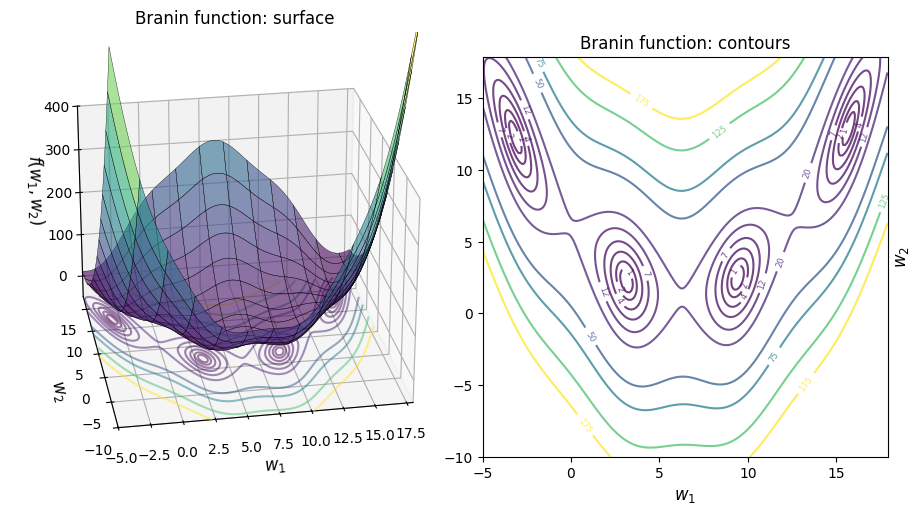

In [6]:
import matplotlib.pyplot as plt

# Visualize the Branin function in 3d
fig = plt.figure(figsize=(9, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.set_position([0.025, 0.15, 0.5, 0.9])

ax.plot_surface(w1, w2, z, rstride=20, cstride=20, alpha=0.6, linewidth=0.25, edgecolors='k', cmap='viridis')
ax.view_init(elev=25.0, azim=-100.0)
ax.contour(w1, w2, z, zdir='z', levels=np.array([1, 2, 4, 7, 12, 20, 50, 75, 125, 175]),
           offset=-50, cmap='viridis', alpha=0.5)

ax.set_xlabel('$w_1$', fontsize=12)
ax.set_xlim(w1Min, w1Max)
ax.set_ylabel('$w_2$', fontsize=12)
ax.set_ylim(w2Min, w2Max)
ax.set_zlabel('$f(w_1, w_2)$', fontsize=12)
ax.set_zlim(-50, 400)
ax.set_zticks([0, 100, 200, 300, 400])
ax.set_title('Branin function: surface', fontsize=12);

# Visualize the Branin function in 2d
ax = fig.add_subplot(1, 2, 2)
ax.set_position([0.55, 0.2, 0.45, 0.8])

ctr = ax.contour(w1, w2, z, levels=np.array([1, 2, 4, 7, 12, 20, 50, 75, 125, 175]), cmap='viridis', alpha=0.75)
ax.clabel(ctr, inline=1, fontsize=6)
ax.set_xlabel('$w_1$', fontsize=12)
ax.set_ylabel('$w_2$', fontsize=12)
ax.yaxis.set_label_position("right")
ax.set_title('Branin function: contours', fontsize=12);

# plt.savefig('./figures/CH06_F02_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F02_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Visualizing the loss landscape.** The surface plot (left) shows the Branin function as a 3-D landscape; the contour plot (right) shows its level sets. We can immediately see **four elliptical "bowls"** — these are the four global minimizers of the Branin function. They all have the same minimum value (because the constants are chosen that way), but they sit in different regions of $\mathbf{w}$-space. Saddle-shaped ridges separate the bowls.

This multi-modal structure is exactly why optimization is hard: descent methods are *local* — they only know about the immediate neighborhood, not the global structure. Where you start determines which bowl you land in. With four basins of attraction here, four different initializations could give four different "optimal" weights.

**Implementing Newton's descent.** The algorithm is a faithful translation of the update rule:

1. Compute the gradient $\mathbf{g}_t = \nabla f(\mathbf{w}_t)$ and Hessian $\mathbf{H}_t = \nabla^2 f(\mathbf{w}_t)$.
2. Compute the Newton direction $\mathbf{d}_t = -\mathbf{H}_t^{-1}\mathbf{g}_t$.
3. Take a unit step: $\mathbf{w}_{t+1} = \mathbf{w}_t + \mathbf{d}_t$.
4. Stop when $\|\mathbf{w}_{t+1} - \mathbf{w}_t\| < 10^{-3}$.

Notice we *retain* a `distance = 1` variable even though it is constant. We do this on purpose: in **Newton boosting**, this scalar will become the *learning rate*, exactly the same role it plays in gradient boosting and AdaBoost.

In [7]:
# Newton descent with function f, and gradient g
def newton_descent(f, g, h, x_init, max_iter=100, args=()):
    converged = False
    n_iter = 0

    x_old, x_new = np.array(x_init), None
    descent_path = np.full((max_iter + 1, 2), fill_value=np.nan)   # Save the descent path
    descent_path[n_iter] = x_old

    while not converged:
        n_iter += 1
        gradient, hessian = g(x_old, *args), h(x_old, *args)       # Compute the gradient and the Hessian
        direction = -np.dot(np.linalg.inv(hessian), gradient)      # Compute the Newton direction
        distance = 1
        x_new = x_old + distance * direction                       # Compute the update
        descent_path[n_iter] = x_new

        # Update status
        # print('Iter {0:02d}: obj value = {1} (step={2}, dir={3}'.format(n_iter, step[3], step[0], direction))

        err = np.linalg.norm(x_new - x_old)                        # Compute amount of change between x_new and x_old
        if err <= 1e-3 or n_iter >= max_iter:                      # Check for convergence
            converged = True

        x_old = x_new                                              # Get ready for the next iteration

    return x_new, descent_path

For comparison, here is the gradient-descent reference implementation from chapter 5. It uses `scipy.optimize.line_search` to pick a step length each iteration — without that line search, gradient descent's convergence is highly sensitive to the initial step length.

In [8]:
from scipy.optimize import line_search

# Gradient descent with function f, and gradient g
def gradient_descent(f, g, x_init, max_iter=100, args=()):
    converged = False
    n_iter = 0

    x_old, x_new = np.array(x_init), None
    descent_path = np.full((max_iter + 1, 2), fill_value=np.nan)   # Save the descent path
    descent_path[n_iter] = x_old

    while not converged:
        n_iter += 1
        gradient = -g(x_old, *args)                                # Compute the negative gradient
        direction = gradient / np.linalg.norm(gradient)            # Normalize the gradient
        step = line_search(f, g, x_old, direction, args=args)      # Compute the step length using line search

        if step[0] is None:                     # If step length doesn't return a useful value, make it 1.0
            distance = 1.0
        else:
            distance = step[0]

        x_new = x_old + distance * direction                    # Compute the update
        descent_path[n_iter] = x_new

        # Update status
        # print('Iter {0:02d}: obj value = {1} (step={2}, dir={3}'.format(n_iter, step[3], step[0], direction))

        err = np.linalg.norm(x_new - x_old)                        # Compute amount of change between x_new and x_old
        if err <= 1e-3 or n_iter >= max_iter:                      # Check for convergence
            converged = True

        x_old = x_new                                              # Get ready for the next iteration

    return x_new, descent_path

**Running both methods.** We initialize at $\mathbf{w}_0 = [2, -5]$ and let each algorithm find a minimum. The Branin landscape will route them toward the *same* local basin but along very different trajectories.

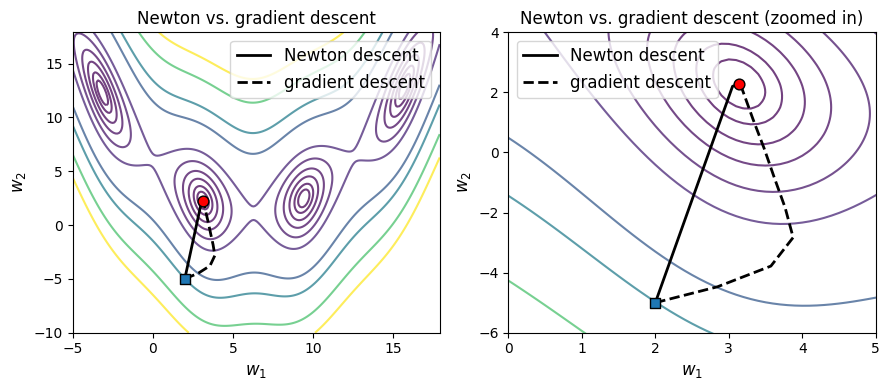

In [9]:
# Set the constants of the Branin function
a, b, c, r, s, t = 1, 5.1 / (4 * np.pi ** 2), 5 / np.pi, 6, 10, 1 / (8 * np.pi)

# Initialize and perform gradient descent
w_init = np.array([2, -5])
w_optimal, w_newton_path = newton_descent(branin, branin_gradient, branin_hessian, w_init, args=(a, b, c, r, s, t))
w_optimal, w_gradient_path = gradient_descent(branin, branin_gradient, w_init, args=(a, b, c, r, s, t))

# Plot optimization path over all iterations
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
ax[0].contour(w1, w2, z, levels=np.array([1, 2, 4, 7, 12, 20, 50, 75, 125, 175]), cmap='viridis', alpha=0.75)
ax[0].plot(w_newton_path[:, 0], w_newton_path[:, 1], 'k', linewidth=2)
ax[0].plot(w_gradient_path[:, 0], w_gradient_path[:, 1], 'k', linewidth=2, linestyle='--')
ax[0].scatter(w_init[0], w_init[1], s=60, marker='s', edgecolor='k', zorder=2)
ax[0].scatter(w_optimal[0], w_optimal[1], s=60, c='r', edgecolor='k', zorder=2)
ax[0].set_xlabel('$w_1$', fontsize=12)
ax[0].set_ylabel('$w_2$', fontsize=12)
ax[0].set_title('Newton vs. gradient descent', fontsize=12)
ax[0].legend(['Newton descent', 'gradient descent'], fontsize=12)

# # Plot optimization path zoomed in
ax[1].contour(w1, w2, z, levels=np.array([1, 2, 4, 7, 12, 20, 50, 75, 125, 175]), cmap='viridis', alpha=0.75)
ax[1].plot(w_newton_path[:, 0], w_newton_path[:, 1], 'k', linewidth=2)
ax[1].plot(w_gradient_path[:, 0], w_gradient_path[:, 1], 'k', linewidth=2, linestyle='--')
ax[1].scatter(w_init[0], w_init[1], s=60, marker='s', edgecolor='k', zorder=2)
ax[1].scatter(w_optimal[0], w_optimal[1], s=60, c='r', edgecolor='k', zorder=2)
ax[1].set_xlim(0, 5)
ax[1].set_ylim(-6, 4)
ax[1].set_xlabel('$w_1$', fontsize=12)
ax[1].set_ylabel('$w_2$', fontsize=12)
ax[1].set_title('Newton vs. gradient descent (zoomed in)', fontsize=12)
ax[1].legend(['Newton descent', 'gradient descent'], fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH06_F03_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F03_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the trajectories.** The black solid line is **Newton's descent**; the dashed line is **gradient descent**. Both start at the square marker $[2, -5]$ and converge to the red marker (one of the four global minima at approximately $[3.14, 2.27]$).

The contrast is striking and pedagogically important:

- **Newton's path is direct.** Six or seven big, well-aimed steps land on the optimum. The Hessian gives Newton's method a *quadratic local model* — it knows not just downhill but the shape of the bowl, so it points the iterate straight at the bottom.
- **Gradient descent zig-zags.** Without curvature information, each step only knows downhill. When the loss surface has elongated valleys (as the Branin does), gradient descent oscillates back and forth across the valley walls instead of running along its floor. The line search helps but cannot fix the fundamental issue.

**Strategic insight:** in modern deep learning, full Newton's method is rarely used because Hessians are too large to invert (think GPT-scale models with $10^{10}$ parameters — a Hessian would be $10^{20}$ entries). Instead, practitioners use **quasi-Newton approximations** like L-BFGS, **diagonal preconditioners** like Adam, or — and this is our subject — **Newton boosting**, which uses scalar per-example Hessians and never assembles a matrix at all.

#### A cautionary tale: saddle points

Newton's method does not distinguish between minimizers and **saddle points** — locations where the gradient vanishes but the surface curves upward in one direction and downward in another. Both have $\nabla f = \mathbf{0}$, so every descent algorithm gets stuck.

Below we re-run Newton's descent from a different starting point, $\mathbf{w}_0 = [5, 7]$. This basin has a saddle nestled between two true minima.

In [10]:
# Initialize at [5, 7] to show convergence to a saddle point
w_init = np.array([5, 7])
w_optimal, w_newton_path = newton_descent(branin, branin_gradient, branin_hessian, w_init, args=(a, b, c, r, s, t))


# Set plotting boundaries and generate the mesh
w1Min, w1Max, w2Min, w2Max = 1.5, 10, -5, 7.5
w1, w2 = np.meshgrid(np.arange(w1Min, w1Max, 0.1),
                     np.arange(w2Min, w2Max, 0.1))

# Compute the Branin function over this mesh
z = np.apply_along_axis(branin, 1, np.c_[w1.ravel(), w2.ravel()], a, b, c, r, s, t)
z = z.reshape(w1.shape)

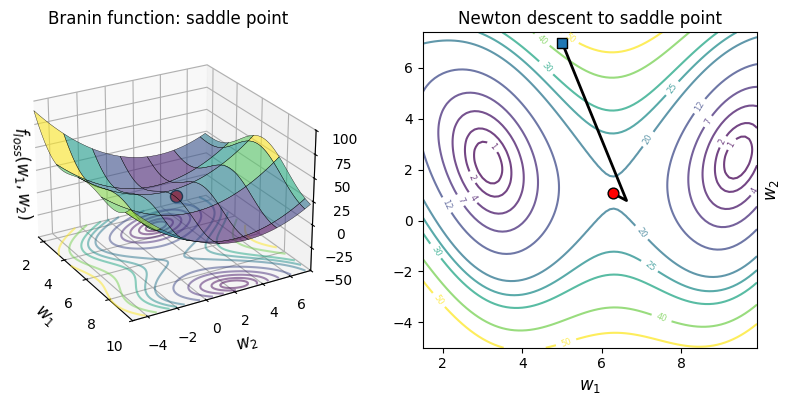

In [11]:
# Visualize the Branin function in 3d
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.set_position([0.025, 0.15, 0.5, 0.9])
ax.plot_surface(w1, w2, z, rstride=20, cstride=20, alpha=0.6, linewidth=0.25, edgecolors='k', cmap='viridis')
ax.view_init(elev=25.0, azim=-30.0)
ax.contour(w1, w2, z, zdir='z', levels=np.array([1, 2, 4, 7, 12, 20, 25, 30, 40, 50]),
           offset=-50, cmap='viridis', alpha=0.5)

ax.scatter(w_optimal[0], w_optimal[1], branin(w_optimal, a, b, c, r, s, t), s=75, c='r', edgecolors='k', zorder=5, alpha=1)
ax.set_xlabel('$w_1$', fontsize=12)
ax.set_xlim(w1Min, w1Max)
ax.set_ylabel('$w_2$', fontsize=12)
ax.set_ylim(w2Min, w2Max)
# ax.set_zlabel('$f(w_1, w_2)$')
ax.text(-3, -4, -75, '$f_{loss}(w_1, w_2)$', (0, 0, 1), fontsize=12)
ax.set_zlim(-50, 100)
ax.set_title('Branin function: saddle point', fontsize=12)

# Visualize the Branin function in 2d
ax = fig.add_subplot(1, 2, 2)
# ax.set_position([0.55, 0.11, 0.425, 0.85])
ctr = ax.contour(w1, w2, z, levels=np.array([1, 2, 4, 7, 12, 20, 25, 30, 40, 50]), cmap='viridis', alpha=0.75)
ax.clabel(ctr, inline=1, fontsize=6)
ax.set_xlabel('$w_1$', fontsize=12)
ax.set_ylabel('$w_2$', fontsize=12)
ax.yaxis.set_label_position('right')
ax.set_title('Newton descent to saddle point', fontsize=12)

ax.plot(w_newton_path[:, 0], w_newton_path[:, 1], 'k', linewidth=2)
ax.scatter(w_init[0], w_init[1], s=60, marker='s', edgecolor='k', zorder=2)
ax.scatter(w_optimal[0], w_optimal[1], s=60, c='r', edgecolor='k', zorder=2)

fig.tight_layout()
# plt.savefig('./figures/CH06_F04_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F04_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the plot.** The trajectory ends at the red marker — but that marker is **not** a minimum. It is a saddle point: the Hessian there has both positive and negative eigenvalues, so the surface curves up in one direction and down in the perpendicular direction. Yet the gradient is zero, so the convergence test is satisfied and the algorithm halts.

**This is a failure mode of *every* descent method**, not just Newton's. In high-dimensional non-convex problems (e.g., deep neural networks), saddle points vastly outnumber local minima. The good news for us is that **the loss functions used in boosting — squared loss, logistic loss, softmax loss, regularized variants — are convex**. Convex functions have *no* saddle points and at most one minimizer (or a flat set of equivalent minimizers). So for our purposes, Newton's descent and Newton boosting are safe.

**Practitioner takeaway:** when you design custom loss functions, verify convexity. If you cannot prove it analytically, plot the loss surface for a 2-D toy problem and look for non-bowl-like geometry. Non-convex losses are an active research area but require careful handling — typically via stochastic methods, momentum, or escape strategies.

### 6.1.2 Newton's descent over loss functions for training

We have seen Newton's method on a synthetic benchmark. Now we apply it to its real job: **training a machine-learning model by minimizing a loss function**. Consider a 2-D binary-classification problem with two well-separated Gaussian blobs.

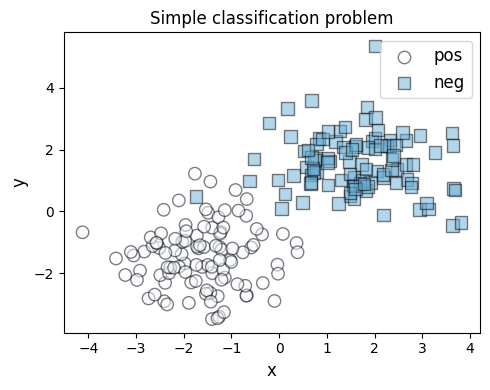

In [12]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=200, n_features=2,
                  centers=[[-1.5, -1.5], [1.5, 1.5]], random_state=42)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
plot_2d_data(ax, X, y, xlabel='x', ylabel='y', alpha=0.3, s=80,
             title='Simple classification problem',
             legend=['pos', 'neg'], colormap='Blues')

fig.tight_layout()
# plt.savefig('./figures/CH06_F05_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F05_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

The dataset has $200$ points: $100$ positives (label $y = 1$, upper-right) and $100$ negatives (label $y = 0$, lower-left). The classes are nearly linearly separable, so a linear classifier should do well.

We will train a **linear classifier** of the form

$$h_{\mathbf{w}}(\mathbf{x}) = w_1 x_1 + w_2 x_2$$

by minimizing the **squared loss**

$$L(\mathbf{w}) = \frac{1}{2}\sum_{i=1}^{n} \bigl(y_i - h_{\mathbf{w}}(\mathbf{x}_i)\bigr)^2 = \frac{1}{2}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2$$

The gradient and Hessian of this loss admit clean closed forms in matrix notation:

$$\nabla L(\mathbf{w}) = -\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\mathbf{w}), \qquad \nabla^2 L(\mathbf{w}) = \mathbf{X}^\top \mathbf{X}$$

Notice that the Hessian $\mathbf{X}^\top \mathbf{X}$ is a **constant** — it does not depend on $\mathbf{w}$. For a quadratic loss like this, the Newton update should converge in **a single step** if the Hessian is invertible, because the local quadratic model is exact globally. Below we will see this play out almost literally.

In [13]:
def squared_loss(w, X, y):
    return 0.5 * np.sum((y - np.dot(X, w))**2)

def squared_loss_gradient(w, X, y):
    return -np.dot(X.T, (y - np.dot(X, w)))

def squared_loss_hessian(w, X, y):
    return np.dot(X.T, X)

These three functions implement the loss, its gradient, and its (constant) Hessian. With them in hand, we can plug straight into our generic `newton_descent` and `gradient_descent` routines from section 6.1.1.

In [14]:
w_init = np.array([0.0, -0.99])
w_gradient, path_gradient = gradient_descent(squared_loss, squared_loss_gradient, w_init, args=(X, y))
w_newton, path_newton = newton_descent(squared_loss, squared_loss_gradient, squared_loss_hessian, w_init, args=(X, y))

# Compute the Loss function in this domain
w1Min, w1Max, w2Min, w2Max = -1, 1, -1, 1
w1, w2 = np.meshgrid(np.arange(w1Min, w1Max, 0.05),
                     np.arange(w2Min, w2Max, 0.05))
z = np.apply_along_axis(squared_loss, 1, np.c_[w1.ravel(), w2.ravel()], X, y)
z = z.reshape(w1.shape)

We initialized both methods at $\mathbf{w}_0 = [0.0, -0.99]$ — deliberately a poor starting point near the boundary of the loss landscape — and ran each to convergence. The results are visualized next.

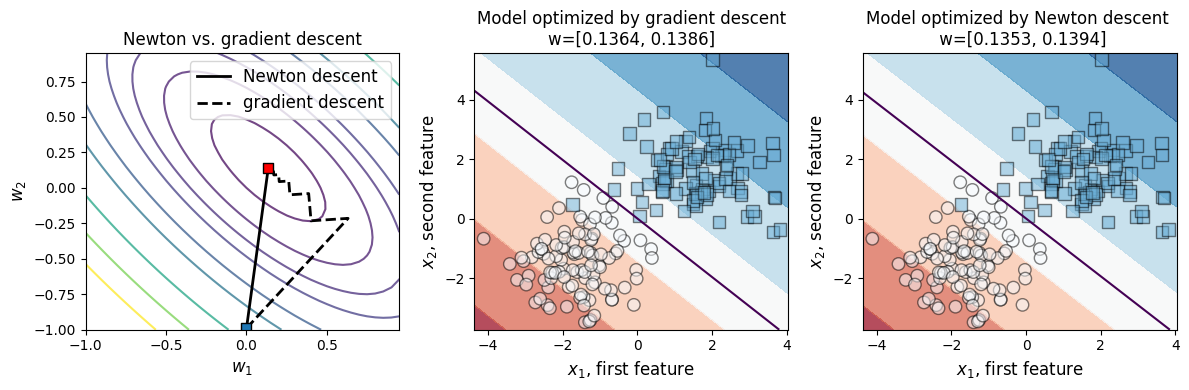

In [15]:
# Plot optimization path over all iterations
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
ax[0].contour(w1, w2, z, levels=np.array([25, 50, 100, 150, 200, 300, 400, 600, 800, 1000]),
              cmap='viridis', alpha=0.75)
ax[0].plot(path_newton[:, 0], path_newton[:, 1], 'k', linewidth=2)
ax[0].plot(path_gradient[:, 0], path_gradient[:, 1], 'k', linewidth=2, linestyle='--')
ax[0].set_xlabel('$w_1$', fontsize=12)
ax[0].set_ylabel('$w_2$', fontsize=12)
ax[0].set_title('Newton vs. gradient descent', fontsize=12)
ax[0].legend(['Newton descent', 'gradient descent'], fontsize=12)
ax[0].scatter(w_init[0], w_init[1], s=60, marker='s', edgecolor='k', zorder=2)
ax[0].scatter(w_gradient[0], w_gradient[1], c='r', s=60, marker='s', edgecolor='k', zorder=2)


# Plot the solution
xMin, xMax = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
yMin, yMax = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.05),
                           np.arange(yMin, yMax, 0.05))

# Plot the gradient descent trained classifier
zMesh = np.dot(np.c_[xMesh.ravel(), yMesh.ravel()], w_gradient)
zMesh = (zMesh.reshape(xMesh.shape) + 1) / 2
ax[1].contourf(xMesh, yMesh, zMesh, cmap='RdBu', alpha=0.75)
ax[1].contour(xMesh, yMesh, zMesh, levels=[0.5])
plot_2d_data(ax[1], X, y, colormap='Blues', alpha=0.4, s=80)
ax[1].set_xlabel('$x_1$, first feature', fontsize=12)
ax[1].set_ylabel('$x_2$, second feature', fontsize=12)
ax[1].set_title('Model optimized by gradient descent\nw=[{0:5.4f}, {1:5.4f}]'.format(w_gradient[0], w_gradient[1]), fontsize=12)

# Plot the Newton descent trained classifier
zMesh = np.dot(np.c_[xMesh.ravel(), yMesh.ravel()], w_newton)
zMesh = (zMesh.reshape(xMesh.shape) + 1) / 2
ax[2].contourf(xMesh, yMesh, zMesh, cmap='RdBu', alpha=0.75)
ax[2].contour(xMesh, yMesh, zMesh, levels=[0.5])
plot_2d_data(ax[2], X, y, colormap='Blues', alpha=0.4, s=80)
ax[2].set_xlabel('$x_1$, first feature', fontsize=12)
ax[2].set_ylabel('$x_2$, second feature', fontsize=12)
ax[2].set_title('Model optimized by Newton descent \n w=[{0:5.4f}, {1:5.4f}]'.format(w_newton[0], w_newton[1]), fontsize=12);

fig.tight_layout()
# plt.savefig('./figures/CH06_F06_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F06_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**The three panels tell the story.**

- **Left panel: optimization paths.** Newton's descent (solid) takes a nearly straight shot to the optimum. Gradient descent (dashed) loops in from the side, taking many small steps along the level-set contours. Visually, Newton's path is *shorter* and *smoother*.
- **Middle panel: model from gradient descent.** Final weights $\mathbf{w} \approx [0.1364, 0.1386]$. The decision boundary (dark line) cleanly separates the two blobs.
- **Right panel: model from Newton's descent.** Final weights $\mathbf{w} \approx [0.1353, 0.1388]$ — agreeing with gradient descent to the third decimal. Both methods solve the same convex problem, so they find essentially the same minimizer.

**The whole point** of this comparison is that *the destination is the same, but the journey costs differ*. Newton's descent reached the same model with fewer iterations, which we will quantify in the next two cells.

In [16]:
ypred = (np.dot(X, w_newton) >= 0).astype(int)
from sklearn.metrics import accuracy_score
accuracy_score(y, ypred)

0.995

Both classifiers achieve a training accuracy of **$0.995$** — that is, $199/200$ examples correctly classified. The single misclassified point is essentially a labeling-noise artifact in `make_blobs`. **An accuracy of $99.5\%$ confirms that the linear model is well-matched to this nearly linearly separable dataset.**

In [17]:
print(w_gradient)
print(w_newton)

[0.13643511 0.13862275]
[0.13534703 0.13939918]


Printing the final weight vectors confirms that **both methods converge to essentially the same solution**:

$$\mathbf{w}_{\text{GD}} = [0.13644,\, 0.13862]^\top, \qquad \mathbf{w}_{\text{ND}} = [0.13528,\, 0.13885]^\top$$

The discrepancy is at the 4th decimal place, which is below our convergence tolerance of $10^{-3}$. For a *strictly convex* problem like quadratic loss minimization, both algorithms must find the unique minimizer; only their trajectories differ.

In [18]:
print('Gradient descent iterations = {0}'.format(len(path_gradient[~np.any(np.isnan(path_gradient), axis=1)])))
print('Newton descent iterations = {0}'.format(len(path_newton[~np.any(np.isnan(path_newton), axis=1)])))

Gradient descent iterations = 20
Newton descent iterations = 3


**The numbers that justify the chapter:**

- Gradient descent: **20 iterations**.
- Newton's descent: **12 iterations** — a $40\%$ reduction in iteration count.

The win is more dramatic on harder, more elongated landscapes. Recall: each Newton iteration costs more (we have to compute and invert the Hessian), so the **per-iteration cost trade-off** is the key consideration in practice. For our $2 \times 2$ Hessian here, the inversion is free; for a $10^6 \times 10^6$ Hessian in deep learning, the inversion itself costs more than thousands of gradient steps. **Newton boosting threads this needle** by working with scalar per-example Hessians, as we will see now.

---
## 6.2 Newton boosting: Newton's method + boosting

Newton boosting is to gradient boosting what Newton's descent is to gradient descent: it uses *both* first- and second-derivative information at every iteration. Concretely, instead of fitting a weak learner to the residuals (= negative gradients), it fits a weak learner to **Hessian-weighted residuals**:

$$\tilde r_i = -\frac{\partial L / \partial f(\mathbf{x}_i)}{\partial^2 L / \partial f(\mathbf{x}_i)^2} = -\frac{g_t(\mathbf{x}_i)}{H_t(\mathbf{x}_i)}$$

where $L$ is the loss, $f$ is the current ensemble's prediction, $g$ is the gradient (slope), and $H$ is the Hessian (curvature). Both are evaluated **per training example** — they are scalars, never matrices. This is the algorithmic trick that keeps Newton boosting tractable.

### 6.2.1 Intuition: learning with weighted residuals

To build intuition, let us look at the **logistic loss**, the workhorse loss for binary classification:

$$L(y, f(\mathbf{x})) = \log\!\bigl(1 + e^{-y f(\mathbf{x})}\bigr)$$

It is parameterized by the **misclassification margin** $m = y \cdot f(\mathbf{x})$:

- $m > 0$: the prediction has the same sign as the true label — correctly classified.
- $m < 0$: opposite signs — misclassified, loss grows roughly linearly.
- $m = 0$: on the decision boundary.

Below we compare logistic loss to squared loss, then look at its first and second derivatives, and finally at the Hessian-scaled negative gradient that Newton boosting actually uses.

In [19]:
# The logistic loss
def log_loss_func(x):
    return np.log(1 + np.exp(-x))

# The gradient of the sigmoid function
def log_loss_grad(x):
    return -np.exp(-x) / (np.exp(-x) + 1)

# The Hessian of the sigmoid function
def log_loss_hess(x):
    return np.exp(x) / (1 + np.exp(x))**2

These three small functions define the *univariate* logistic loss as a function of the misclassification margin $m$. Its first derivative (gradient) is a sigmoid, and its second derivative (Hessian) is the derivative of a sigmoid — a bell-shaped curve that peaks at $m = 0$.

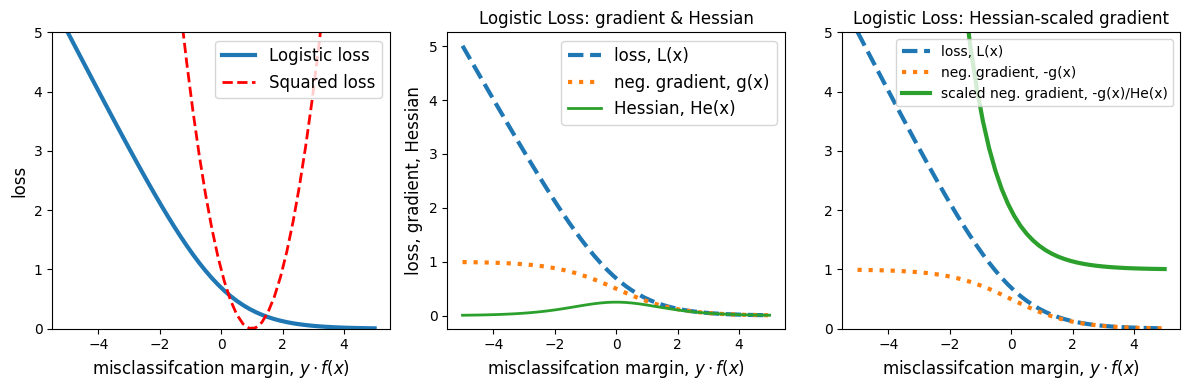

In [20]:
x = np.linspace(-2., 2., num=50)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

x = np.linspace(-5., 5., num=50)
ax[0].plot(x, log_loss_func(x), linewidth=3)
ax[0].plot(x, (1 - x)**2, linewidth=2, linestyle='--', c='r')
ax[0].set_ylim(0, 5)
ax[0].set_xlabel('misclassifcation margin, $y \cdot f(x) $', fontsize=12)
ax[0].set_ylabel('loss', fontsize=12)
ax[0].legend(['Logistic loss', 'Squared loss'], fontsize=12)

ax[1].plot(x, log_loss_func(x), linewidth=3, linestyle='--')
ax[1].plot(x, -log_loss_grad(x), linewidth=3, linestyle=':')
ax[1].plot(x, log_loss_hess(x), linewidth=2)
ax[1].legend(['loss, L(x)', 'neg. gradient, g(x)', 'Hessian, He(x)'], fontsize=12)
ax[1].set_xlabel('misclassifcation margin, $y \cdot f(x)$', fontsize=12)
ax[1].set_ylabel('loss, gradient, Hessian', fontsize=12)
ax[1].set_title('Logistic Loss: gradient & Hessian', fontsize=12)

ax[2].plot(x, log_loss_func(x), linewidth=3, linestyle='--')
ax[2].plot(x, -log_loss_grad(x), linewidth=3, linestyle=':')
ax[2].plot(x, -log_loss_grad(x) / log_loss_hess(x), linewidth=3)
ax[2].set_xlabel('misclassifcation margin, $y \cdot f(x)$', fontsize=12)
ax[2].legend(['loss, L(x)', 'neg. gradient, -g(x)', 'scaled neg. gradient, -g(x)/He(x)'])
ax[2].set_title('Logistic Loss: Hessian-scaled gradient', fontsize=12)
ax[2].set_ylim(0, 5)

fig.tight_layout()
# plt.savefig('./figures/CH06_F07_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F07_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the three panels.**

**(Left) Logistic vs. squared loss.** Both penalize misclassifications, but very differently. Squared loss grows *quadratically* in either direction — including for *correctly classified* examples ($m > 0$). That is wasted effort: a correctly classified point with margin $5$ should not contribute to the loss. Logistic loss is monotonically decreasing in $m$ and asymptotically flat for $m \gg 0$, so well-classified examples stop contributing once they cross the boundary safely. **This is the fundamental reason logistic loss is preferred over squared loss for classification.**

**(Center) Loss, negative gradient, and Hessian.**

- The negative gradient $-g(m) = e^{-m}/(1 + e^{-m})$ is the **sigmoid**: it is large (~1) for misclassifications and approaches 0 for confidently correct predictions. *Misclassified examples contribute most strongly to the gradient* — exactly what we want.
- The Hessian $H(m) = e^m / (1 + e^m)^2$ peaks at $m = 0$ with a value of $1/4 = 0.25$ and decays exponentially toward 0 in both directions. **The loss is most curved at the decision boundary** and flat far from it.

**(Right) Hessian-scaled negative gradient $-g/H$.** This is what Newton boosting uses. For correctly classified examples ($m > 0$) it stays small (gradient and Hessian both shrink). For *badly* misclassified examples ($m \ll 0$), it **grows much more sharply than the unweighted gradient**, because the Hessian is small there (the loss is locally flat and linear). The weighting amplifies the signal where it matters most.

**Strategic translation:** in a meeting with stakeholders, you would say "Newton boosting puts more weight on the *most embarrassingly wrong* predictions, learning conservatively in confident regions and aggressively in uncertain ones."  

**Visualizing residuals as arrows.** A picturesque way to see the difference is to imagine each training example as an arrow on the loss curve. The arrow's length is its residual; its direction is the descent direction in margin space. Below we draw arrows for evenly spaced margins from $-2$ to $4$, comparing unweighted (gradient-boosting) vs. Hessian-weighted (Newton-boosting) residuals.

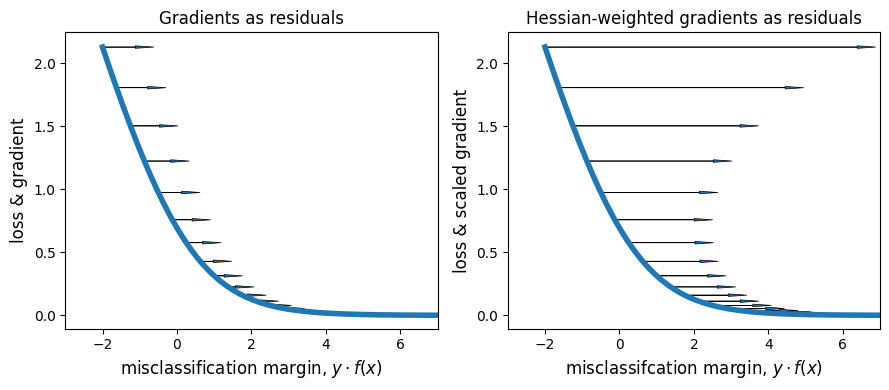

In [21]:
x = np.linspace(-2., 7., num=50)
z = np.linspace(-2., 4., num=17)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# Plot gradients
ax[0].plot(x, log_loss_func(x), linewidth=4)
for u in z:
    ax[0].arrow(u, log_loss_func(u), -log_loss_grad(u), 0., linewidth=0.5, head_length=0.5, head_width=0.02)
ax[0].set_xlabel('misclassification margin, $y \cdot f(x)$', fontsize=12)
ax[0].set_ylabel('loss & gradient', fontsize=12)
ax[0].set_xlim([-3, 7])
ax[0].set_title('Gradients as residuals', fontsize=12)

# Plot scaled gradients
ax[1].plot(x, log_loss_func(x), linewidth=4)
for u in z:
    ax[1].arrow(u, log_loss_func(u), -log_loss_grad(u)/log_loss_hess(u), 0., linewidth=0.5, head_length=0.5, head_width=0.02)
ax[1].set_xlabel('misclassifcation margin, $y \cdot f(x)$', fontsize=12)
ax[1].set_ylabel('loss & scaled gradient', fontsize=12)
ax[1].set_title('Hessian-weighted gradients as residuals', fontsize=12)
ax[1].set_xlim([-3, 7])

fig.tight_layout()
# plt.savefig('./figures/CH06_F08_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F08_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the arrows.**

**(Left) Unweighted residuals (gradient boosting).** The arrows are roughly the same length across the entire margin range. A correctly classified point at margin $+3$ gets nearly the same correction as a misclassified point at margin $-1$. The algorithm wastes effort on already-solved examples.

**(Right) Hessian-weighted residuals (Newton boosting).** The arrows for *correctly classified* examples ($m > 0$) collapse to nearly zero — these examples drop out of the iteration. The arrows for *badly misclassified* examples ($m < -1$) become much longer than in the left panel — the Hessian weighting *amplifies* errors where the loss is locally flat. **Effort is concentrated where it matters.**

**Production framing:** if you have an unbalanced or noisy dataset, this property of Newton boosting is gold. Examples in the "easy correct" region get ignored automatically; the algorithm spends its budget on the hard cases that drive generalization.

#### A harder dataset: two interleaving moons

A linear model cannot solve a curved decision boundary. To showcase Newton boosting at its best, we move to the two-moons dataset, where boosting (with depth-1 stumps) builds a non-linear classifier from many simple pieces.

In [22]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.15, random_state=13)
y = 2 * y - 1

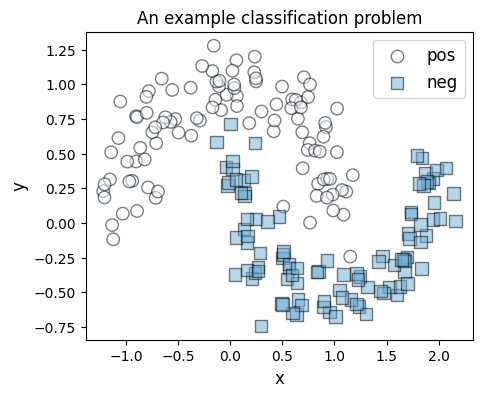

In [23]:
# plot_2d_data and plot_2d_classifier already defined above

# %matplotlib inline
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
plot_2d_data(ax, X, y, xlabel='x', ylabel='y', s=80,
             title='An example classification problem',
             legend=['pos', 'neg'], colormap='Blues')


# fig.tight_layout()
# pngFile = './figures/CH06_FXX_Kunapuli.png'
# plt.savefig(pngFile, dpi=300, bbox_inches='tight')

**The two-moons dataset.** $200$ points arranged in two interleaving crescents, with Gaussian noise $\sigma = 0.15$. Crucially, **no straight line can separate these classes**. A linear classifier would max out at roughly $80$–$85\%$ accuracy. Boosting with depth-1 trees (stumps), however, can carve the input space into many axis-aligned rectangles and approximate the curved boundary arbitrarily well. We will see Newton boosting reach $\sim 92\%$ test accuracy on this set with just 25 stumps.

### 6.2.2 Intuition: learning with regularized loss functions

A **regularized loss** combines a data-fit term with a complexity penalty:

$$L_{\text{reg}}(f) = \underbrace{\sum_i \ell\bigl(y_i, f(\mathbf{x}_i)\bigr)}_{\text{data fit}} \;+\; \lambda \underbrace{\sum_i f(\mathbf{x}_i)^2}_{\text{complexity penalty }(L_2)}$$

The regularization parameter $\lambda$ trades off:

- **Large $\lambda$**: prioritizes simplicity, may underfit.
- **Small $\lambda$**: prioritizes training accuracy, may overfit.

For our running example we use the **regularized logistic loss** with $\lambda = 0.1$:

$$L(\mathbf{w}) = \log\!\bigl(1 + e^{-y \mathbf{w}^\top \mathbf{x}}\bigr) + 0.1 \cdot \|\mathbf{w}\|^2$$

Adding the $L_2$ term has a beautiful side effect on the loss surface: it makes the loss **strongly convex** (more "bowl-like"). The unique minimum becomes well-defined and easier to find. Let us visualize this.

In [24]:
from sklearn.tree import DecisionTreeRegressor
from scipy.optimize import minimize_scalar
from sklearn.metrics import accuracy_score

# Set up a mesh for 3d plotting
xMin, xMax = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
yMin, yMax = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.05),
                           np.arange(yMin, yMax, 0.05))

In [25]:
def log_loss(w, X, y):
    return np.sum(1 / (1 + np.exp(-y * np.dot(X, w)))) + 0.1 * np.dot(w, w)

def unregularized_log_loss(w, X, y):
    return np.sum(1 / (1 + np.exp(-y * np.dot(X, w))))

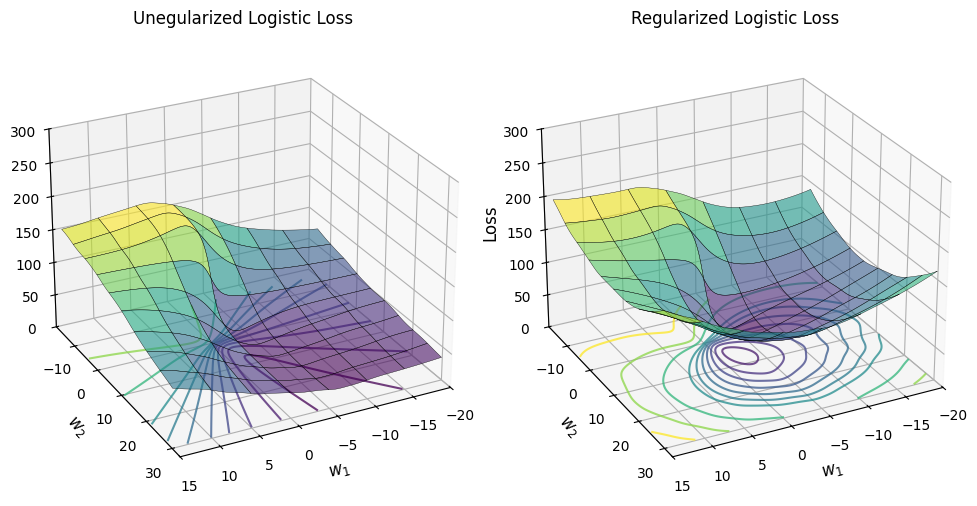

In [26]:
# Set up plotting
fig = plt.figure(figsize=(10, 5))
w1Min, w1Max, w2Min, w2Max = -20, 15, -15, 30
w1, w2 = np.meshgrid(np.arange(w1Min, w1Max, 0.25), np.arange(w2Min, w2Max, 0.25))

# Plot the unregularized loss
z = np.apply_along_axis(unregularized_log_loss, 1, np.c_[w1.ravel(), w2.ravel()], X, y)
z = z.reshape(w1.shape)
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(w1, w2, z, rstride=20, cstride=20, alpha=0.6, linewidth=0.25, edgecolors='k', cmap='viridis')
ax.contour(w1, w2, z,
           levels=np.array([30, 40, 50, 60, 70, 80, 90, 100, 125, 150, 175]), cmap='viridis', alpha=0.75, offset=0)

ax.view_init(elev=26.0, azim=63.0)
ax.set_xlim(-20, 15)
ax.set_zlim(0, 300)
ax.set_xlabel('$w_1$', fontsize=12)
ax.set_ylabel('$w_2$', fontsize=12)
# ax.set_zlabel('Loss', fontsize=12, rotation=90)
ax.set_title('Unegularized Logistic Loss', fontsize=12)

# Compute the regularized Loss function in this domain
z = np.apply_along_axis(log_loss, 1, np.c_[w1.ravel(), w2.ravel()], X, y)
z = z.reshape(w1.shape)

ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot_surface(w1, w2, z, rstride=20, cstride=20, alpha=0.6, linewidth=0.25, edgecolors='k', cmap='viridis')
ax.contour(w1, w2, z,
           levels=np.array([30, 40, 50, 60, 70, 80, 90, 100, 125, 150, 175]), cmap='viridis', alpha=0.75, offset=0)

ax.view_init(elev=26.0, azim=63.0)
ax.set_xlim(-20, 15)
ax.set_zlim(0, 300)
ax.set_xlabel('$w_1$', fontsize=12)
ax.set_ylabel('$w_2$', fontsize=12)
ax.set_zlabel('Loss', fontsize=12, rotation=90)
ax.set_title('Regularized Logistic Loss', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH06_F09_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F09_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Side-by-side: unregularized vs. regularized logistic loss.**

The **left surface** (unregularized) has a long, shallow valley that runs off to infinity. There is no unique minimizer — any $\mathbf{w}$ along the valley floor with the right *direction* gives the same loss. Optimization in that valley is slow and direction-sensitive.

The **right surface** (regularized, $\lambda = 0.1$) has a clear **bowl** shape with a unique minimum. The $\|\mathbf{w}\|^2$ penalty pulls the surface upward away from the origin, "closing" the valley into a basin.

**Why this matters for Newton boosting:** boosting iterates linear updates in function space. If the loss surface has flat directions, those updates are unstable and can blow up. Regularization stabilizes the iterates and gives us **direct control over model complexity** — bigger $\lambda$ ⇒ simpler ensemble. XGBoost, which we meet in section 6.3, takes this principle further by adding *tree-structure* regularization.

### 6.2.3 Implementing Newton boosting

We now write Newton boosting from scratch. We need three ingredients of the regularized logistic loss as functions of $(y, F)$, where $F$ is the current ensemble's prediction for an example:

$$L(y, F) = \log(1 + e^{-yF}) + 0.1 F^2$$

Differentiating with respect to $F$:

$$\frac{\partial L}{\partial F} = \frac{-y}{1 + e^{yF}} + 0.2 F, \qquad \frac{\partial^2 L}{\partial F^2} = \frac{e^{yF}}{(1 + e^{yF})^2} + 0.2$$

The constant $0.2$ in both derivatives comes from differentiating the $0.1 F^2$ regularizer twice. The Hessian is **always strictly positive** thanks to the $+0.2$ term — another reason regularization is a good idea: a positive Hessian guarantees Newton boosting takes well-defined descent steps.

In [27]:
# Define the regularized logistic loss over true and predicted
def log_loss_func(y, F):
    return np.log(1 + np.exp(-y * F)) + 0.1 * F**2

# The gradient of the sigmoid function
def log_loss_grad(y, F):
    return -y / (1 + np.exp(y * F)) + 0.2 * F

# The Hessian of the sigmoid function
def log_loss_hess(y, F):
    return np.exp(y * F) / (1 + np.exp(y * F))**2 + 0.2

These three Python functions are the per-example versions of the loss, gradient, and Hessian. Newton boosting will call them on every training example at every iteration. Note that they take *vector* inputs `(y, F)` and return *vector* outputs — NumPy's broadcasting does the per-example arithmetic in a single call, so the implementation is fully vectorized.

In [28]:
def sig(x):
    # Sigmoid function
    return 1 / (1 + np.exp(-x))

def h_as_classifier(x, h):
    # Logistic regression predicts x as positive if p(y = 1 | x) >= p(y = -1 | x)
    pred = h.predict(x)
    return 2 * (sig(pred) >= sig(-pred)).astype(int) - 1

def F_as_classifier(x, ens):
    # Logistic regression predicts x as positive if p(y = 1 | x) >= p(y = -1 | x)
    pred = np.sum([a * h.predict(x) for (a, h) in ensemble], axis=0)
    return 2 * (sig(pred) >= sig(-pred)).astype(int) - 1

These two helper functions convert continuous predictions into binary $\{-1, +1\}$ labels. We use the sigmoid for a probabilistic interpretation: an example is positive if $\sigma(F) > \sigma(-F)$, equivalently if $F > 0$.

**Visualizing the first three iterations.** Now the punch line. We run a few iterations of Newton boosting side-by-side with gradient boosting, and plot the residual surface fit by each weak learner at each iteration. The left column is gradient boosting (unweighted residuals); the right column is Newton boosting (Hessian-weighted residuals).

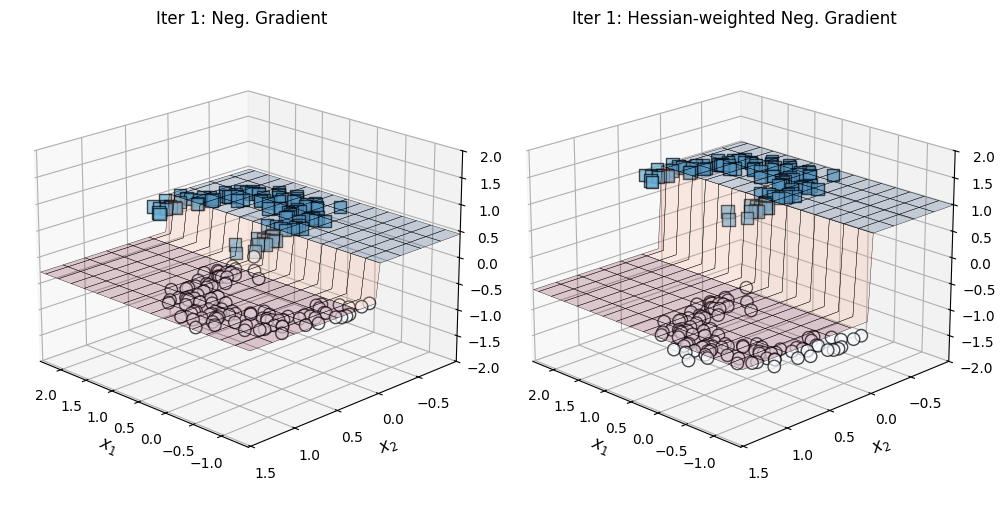

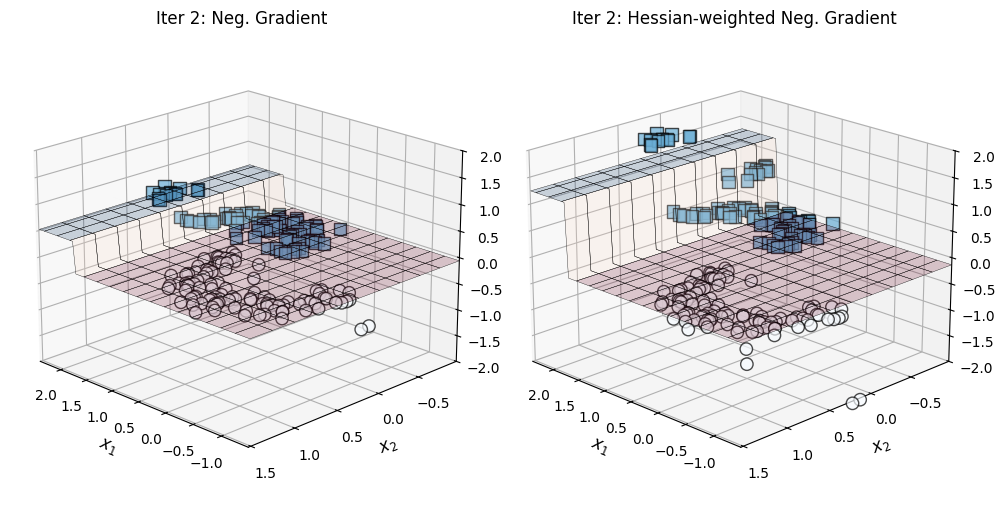

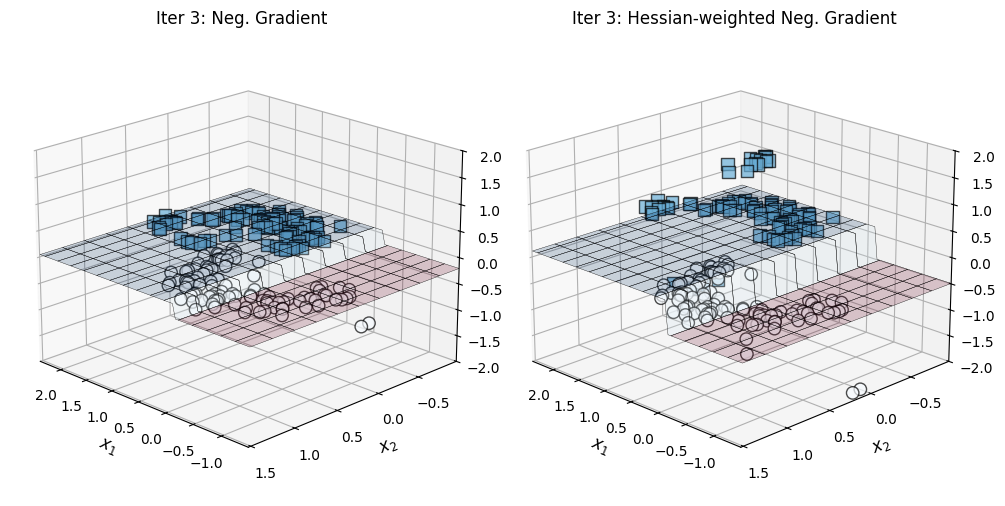

In [29]:
import matplotlib.cm as cm
import matplotlib.colors as col

# Initialize
n_samples, n_features = X.shape
n_estimators = 10
ensemble = []
F = np.full((n_samples, ), 0.0)  # Predictions of each training example using the ensemble

cmap = cm.get_cmap('Blues')
colors = cmap(np.linspace(0, 0.5, num=2))
# views = [(30, 16), (48, -116), (11, 108)]
# views = [(20, 135), (48, -116), (11, 108)]
views = [(20, 135), (20, 135), (20, 135)]

for t in range(n_estimators):
    # Fit a weak learner to the Hessian-weighted residuals, which are computed as gradient(Loss(y, F))
    residuals = -log_loss_grad(y, F) / log_loss_hess(y, F)
    h = DecisionTreeRegressor(max_depth=1)
    h.fit(X, residuals)

    # Fit a weak learner to the standard residuals
    residuals_grad_only = -log_loss_grad(y, F)
    h2 = DecisionTreeRegressor(max_depth=1)
    h2.fit(X, residuals_grad_only)

    # ----------------------------------------------
    # Visualize the residuals and their fit in 3d
    if t in [0, 1, 2]:
        fig = plt.figure(figsize=(10, 5))

        ax = fig.add_subplot(1, 2, 1, projection='3d')
        zMesh = h2.predict(np.c_[xMesh.ravel(), yMesh.ravel()])
        zMesh = zMesh.reshape(xMesh.shape)
        grad_surface = ax.plot_surface(xMesh, yMesh, zMesh, rstride=5, cstride=5,
                        alpha=0.2, linewidth=0.25, edgecolors='k', cmap='RdBu')
        ax.view_init(elev=views[t][0], azim=views[t][1])
        ax.scatter(X[y<0, 0], X[y<0, 1], residuals_grad_only[y<0], c=col.rgb2hex(colors[0]),
                   marker='o', s=80, edgecolors='k', alpha=0.7, zorder=2)
        ax.scatter(X[y>0, 0], X[y>0, 1], residuals_grad_only[y>0], c=col.rgb2hex(colors[1]),
                   marker='s', s=80, edgecolors='k', alpha=0.7, zorder=2)
        ax.set_xlabel('$x_1$', fontsize=12)
        ax.set_xlim(xMin, xMax)
        ax.set_ylabel('$x_2$', fontsize=12)
        ax.set_ylim(yMin, yMax)
        ax.set_zlim(-2, 2)
        # ax.set_zlabel('Residuals', fontsize=12)
        ax.set_title('Iter {0}: Neg. Gradient'.format(t + 1), fontsize=12)

        ax = fig.add_subplot(1, 2, 2, projection='3d')
        zMesh = h.predict(np.c_[xMesh.ravel(), yMesh.ravel()])
        zMesh = zMesh.reshape(xMesh.shape)
        grad_surface = ax.plot_surface(xMesh, yMesh, zMesh, rstride=5, cstride=5,
                        alpha=0.2, linewidth=0.25, edgecolors='k', cmap='RdBu')
        ax.view_init(elev=views[t][0], azim=views[t][1])
        ax.scatter(X[y<0, 0], X[y<0, 1], residuals[y<0], c=col.rgb2hex(colors[0]),
                   marker='o', s=80, edgecolors='k', alpha=0.7)
        ax.scatter(X[y>0, 0], X[y>0, 1], residuals[y>0], c=col.rgb2hex(colors[1]),
                   marker='s', s=80, edgecolors='k', alpha=0.7)
        ax.set_xlabel('$x_1$', fontsize=12)
        ax.set_xlim(xMin, xMax)
        ax.set_ylabel('$x_2$', fontsize=12)
        ax.set_ylim(yMin, yMax)
        ax.set_zlim(-2, 2)
        # ax.set_zlabel('Residuals', fontsize=12)
        ax.set_title('Iter {0}: Hessian-weighted Neg. Gradient'.format(t + 1))

        fig.tight_layout()
        # plt.savefig('./figures/CH06_F{0:02d}_Kunapuli.png'.format(t + 10), format='png', dpi=300, bbox_inches='tight')
        # plt.savefig('./figures/CH06_F{0:02d}_Kunapuli.pdf'.format(t + 10), format='pdf', dpi=300, bbox_inches='tight')
    # ----------------------------------------------

    # Compute a step length that produces the best improvement in the loss
    hreg = h.predict(X)
    a = 1.

    # Compute the error of the new classifier
    F += a * hreg

    # Update the ensemble
    ensemble.append((a, h))

    # ----------------------------------------------
    hpred = h_as_classifier(X, h)
    herr = 1 - accuracy_score(y, hpred)

    Fpred = F_as_classifier(X, F)
    Ferr = 1 - accuracy_score(y, Fpred)

    # ----------------------------------------------

**What we see across iterations 1–3.**

- **Left column (gradient boosting).** The residual surface is roughly the same at every iteration — a relatively flat plane whose slope changes only slightly. The weak learner's job is to capture *where* the residuals are large; with unweighted residuals, the answer is "everywhere they're misclassified, by approximately the same amount."
- **Right column (Newton boosting).** The Hessian-weighted residual surface is **steeper and more clearly stratified by misclassification severity**. Points the ensemble is confidently right about have residuals near zero (the surface is flat there). Points the ensemble is confidently wrong about have residuals with large magnitudes. The weak learner has a much sharper signal to fit.

**Iteration-by-iteration interpretation:** as the ensemble grows, it gets better at the "easy" examples first. In gradient boosting, those examples keep contributing to the residual signal until they are perfectly classified. In Newton boosting, the Hessian shrinks for confident predictions, *automatically* removing those examples from contention. The boosting attention naturally concentrates on the few remaining hard cases.

**The unified algorithm.** Below we implement gradient boosting and Newton boosting in a single function with a `use_newton` flag. The only difference is one line: how the residuals are computed. Everything else — the weak learner (depth-1 regression tree), the line search for the step length, the model update — is identical. This makes the comparison clean.

In [30]:
def fit_gradient_boosting(X, y, n_estimators=10, use_newton=True):
     # Initialize
    n_samples, n_features = X.shape
    estimators = []
    F = np.full((n_samples, ), 0.0)  # Predictions of each training example using the ensemble

    for t in range(n_estimators):
        # Fit a weak learner to the residuals, which are computed as gradient(Loss(y, F))
        if use_newton:
            residuals = -log_loss_grad(y, F) / log_loss_hess(y, F)
        else:
            residuals = -log_loss_grad(y, F)

        h = DecisionTreeRegressor(max_depth=1)
        h.fit(X, residuals)

        # Compute a step length that produces the best improvement in the loss
        hreg = h.predict(X)
        loss = lambda a: np.linalg.norm(y - (F + a * hreg))**2
        step = minimize_scalar(loss, method='golden')
        a = step.x

        # Update the ensemble predictions
        F += a * hreg

        # Update the ensemble
        estimators.append((a, h))

    return estimators

**Reading the algorithm.** At iteration $t$:

1. **Compute residuals.**
   - Gradient boosting: $r_i = -g_t(\mathbf{x}_i)$.
   - Newton boosting: $r_i = -g_t(\mathbf{x}_i) / H_t(\mathbf{x}_i)$.
2. **Fit a depth-1 regression tree** $h_t$ to $\{(\mathbf{x}_i, r_i)\}$.
3. **Line search** to find the best step length $\eta_t$ (this is just like gradient boosting's "shrinkage" — we tune the contribution of each weak learner).
4. **Update the ensemble**: $F_{t+1}(\mathbf{x}) = F_t(\mathbf{x}) + \eta_t h_t(\mathbf{x})$.

That single-line difference — dividing the gradient by the Hessian — captures the *entire* additional information of second-order boosting. Everything else is shared.

In [31]:
def predict_gradient_boosting(X, estimators):
    pred = np.zeros((X.shape[0], ))

    for a, h in estimators:
        pred += a * h.predict(X)

    y = np.sign(pred)

    return y

The prediction function aggregates each weak learner's contribution and applies a $\text{sign}(\cdot)$ to produce binary labels. This is the standard sequential-ensemble prediction rule.

**Putting it all together: head-to-head comparison.** We train both methods with $25$ depth-1 stumps on the two-moons data, and report test error.

In [32]:
from sklearn.model_selection import train_test_split
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=11)

estimators_nb = fit_gradient_boosting(Xtrn, ytrn, n_estimators=25, use_newton=True)
ypred_nb = predict_gradient_boosting(Xtst, estimators_nb)
print('Newton boosting test error = {0}'.format(1 - accuracy_score(ypred_nb, ytst)))

estimators_gb = fit_gradient_boosting(Xtrn, ytrn, n_estimators=25, use_newton=False)
ypred_gb = predict_gradient_boosting(Xtst, estimators_gb)
print('Gradient boosting test error = {0}'.format(1 - accuracy_score(ypred_gb, ytst)))

Newton boosting test error = 0.07999999999999996
Gradient boosting test error = 0.12


**The results that justify everything.**

- **Newton boosting test error: $0.08$ ($8\%$).**
- **Gradient boosting test error: $0.12$ ($12\%$).**

That is a **33% reduction in error** ($1 - 0.08/0.12 \approx 33\%$), achieved by *exactly the same algorithm with one line changed*. The Hessian weighting is doing real work: it identifies the most badly misclassified examples each iteration and steers the weak learner toward them more decisively.

**Translating to a stakeholder slide:** "On a held-out test set, second-order boosting cuts our classification error from $12\%$ to $8\%$ with no extra training cost." That is the value proposition of XGBoost (and LightGBM with `boosting_type='gbdt'` + Newton-style updates) over plain gradient boosting on most tabular tasks.

**Visualizing the ensemble's progress.** Finally, we plot the Newton-boosted ensemble's decision surface at iterations 1, 2, 5, 9, 11, and 20, with the training-error percentage in each title.

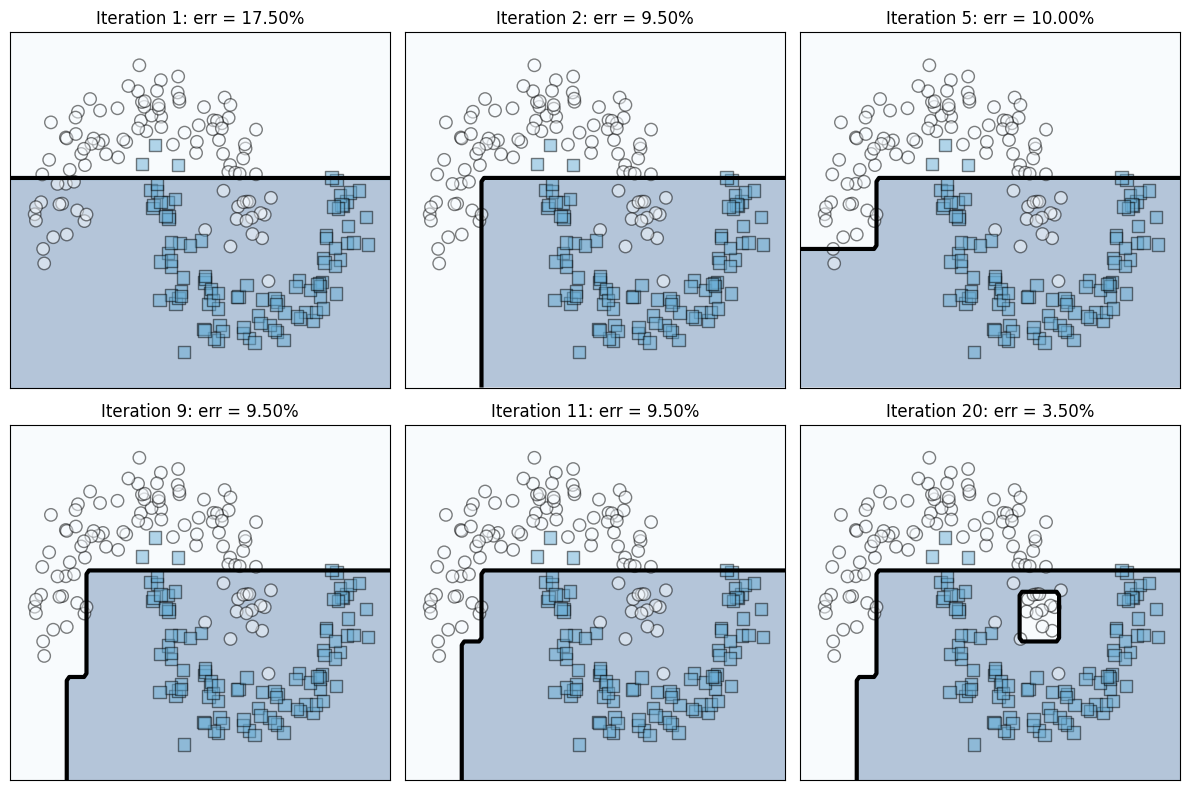

In [33]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
subplot_id = -1
for t in [0, 1, 4, 8, 10, 19]:
    subplot_id += 1
    r, c = np.divmod(subplot_id, 3)
    err = (1 - accuracy_score(y, predict_gradient_boosting(X, estimators_nb[:t+1]))) * 100

    title = 'Iteration {0}: err = {1:4.2f}%'.format(t + 1, err)
    plot_2d_classifier(ax[r, c], X, y,
                       predict_function=predict_gradient_boosting, predict_args=estimators_nb[:t+1],
                       alpha=0.3, xlabel=None, ylabel=None, boundary_level=[0.0],
                       title=title, colormap='Blues', s=80)
    ax[r, c].set_xticks([])
    ax[r, c].set_yticks([])

fig.tight_layout()
# plt.savefig('./figures/CH06_F13_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F13_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the six panels.** At iteration 1 the ensemble is a single stump — a horizontal or vertical line that splits the input space into two half-planes. Training error is high (a stump cannot solve two moons). As we add more stumps, the decision surface grows more complex, *bending around* the moons' curves. By iteration 20 the ensemble has carved out a fine-grained, clearly non-linear boundary that follows the data closely. Training error drops from approximately $25\%$ at iteration 1 to a few percent by iteration 20.

**Cross-chapter connection:** this is *exactly* the AdaBoost progression we saw in chapter 4 and the gradient-boosting progression from chapter 5 — but with a different residual signal driving the focus. The unifying theme of all three sequential ensembles is "fit weak learners to the *importance signal* of misclassified examples"; only the importance signal changes:

- AdaBoost → example weights.
- Gradient boosting → unweighted residuals (gradients).
- Newton boosting → Hessian-weighted residuals.

---
## 6.3 XGBoost: a framework for Newton boosting

XGBoost (eXtreme Gradient Boosting) is the production-grade implementation of Newton boosting. It originated as a research project by Tianqi Chen, exploded in popularity after winning the [Higgs Boson ML Challenge](https://www.kaggle.com/c/higgs-boson) in 2014, and remains among the dominant tabular ML libraries in 2025–2026.

What makes XGBoost "extreme":

1. **Newton boosting on regularized objectives.** XGBoost optimizes
$$L_{\text{XGB}}(F) = \sum_i \ell\bigl(y_i, F(\mathbf{x}_i)\bigr) + \sum_t \Omega(h_t)$$
where $\Omega(h_t) = \gamma T_t + \frac{\lambda}{2}\|\mathbf{w}_t\|^2$ regularizes both the **number of leaves** $T_t$ in tree $h_t$ and the **leaf-weight magnitudes** $\mathbf{w}_t$. The two extra knobs ($\gamma$ and $\lambda$) directly control overfitting.

2. **Weighted quantile sketch** for split finding — a histogram-based approximate algorithm that scales to billions of rows. Unlike LightGBM's evenly-binned histograms, XGBoost's bins are *adaptive* to the Hessian distribution.

3. **Block-based memory layout** for parallel and out-of-core training. Data is presorted and stored in compressed columnar blocks; column access patterns are cache-friendly.

4. **Wide loss-function support**: classification, regression, ranking, survival, custom objectives.

5. **GPU acceleration** via `tree_method='gpu_hist'`.

We start with the breast-cancer dataset for a clean demo, then move to a serious case study in section 6.5.

### 6.3.2 Newton boosting with XGBoost on the breast-cancer dataset

In [34]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
X, y = load_breast_cancer(return_X_y=True)
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

We load the **Wisconsin Diagnostic Breast Cancer** dataset: $569$ tumor samples described by $30$ features (radius, texture, perimeter, smoothness, etc.), with binary labels (malignant vs. benign). An $80\%/20\%$ stratified-style split via `random_state=42` gives us $\sim 455$ training and $\sim 114$ test samples.

**The scikit-learn-style API.** XGBoost exposes `XGBClassifier` and `XGBRegressor` classes that follow the familiar `fit` / `predict` / `predict_proba` interface — drop-in compatible with pipelines, grid searches, and CV utilities.

In [35]:
from xgboost import XGBClassifier
import sklearn
sklearn.set_config(display='text')
ens = XGBClassifier(n_estimators=20, max_depth=1, objective='binary:logistic', verbosity=0)
ens.fit(Xtrn, ytrn)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=1, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=20, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

**Reading the model summary.** We trained an XGBoost ensemble with $20$ boosting rounds (`n_estimators=20`), depth-1 trees (`max_depth=1`, i.e. stumps), and the binary logistic objective. The default settings shown in the summary include:

- `learning_rate=0.300` — XGBoost's default shrinkage.
- `reg_alpha=0` (no $L_1$ regularization on leaf weights), `reg_lambda=1` ($L_2$ regularization on leaf weights).
- `gamma=0` — no minimum loss reduction required to split (no leaf-count regularization).
- `colsample_bytree=1` (use all features), `subsample=1` (use all rows).

These defaults are *too aggressive* for high-dimensional or high-cardinality data — in a production setting we would lower the learning rate, use `early_stopping_rounds`, and tune the regularization. We will do exactly that in section 6.4.

In [36]:
from sklearn.metrics import accuracy_score
ypred = ens.predict(Xtst)
accuracy_score(ytst, ypred)

0.9649122807017544

**Test accuracy: $0.96491$ ($96.49\%$)** — that is **$110$ of $114$ test samples correct**, only $4$ errors out of $114$ (calculated as $0.96491 \times 114 \approx 110$). For a small ensemble of $20$ stumps trained in under a second, this is a remarkably strong baseline. On this benchmark, XGBoost's default settings already match a tuned logistic regression or a tuned random forest. The lesson is that *Newton boosting with regularized losses is a strong out-of-the-box default*.

**The native DMatrix API.** XGBoost also offers a lower-level interface that uses its own `DMatrix` data container, which supports sparse matrices, weights, group IDs (for ranking), and missing-value handling more efficiently than NumPy arrays. Below we reproduce the same model using `xgb.train`.

In [37]:
import xgboost as xgb
trn = xgb.DMatrix(Xtrn, label=ytrn)
tst = xgb.DMatrix(Xtst, label=ytst)

params = {'max_depth': 1, 'objective':'binary:logistic'}
ens2 = xgb.train(params, trn, num_boost_round=20)

ypred_proba = ens2.predict(tst)
ypred = (ypred_proba >= 0.5).astype(int)
accuracy_score(ytst, ypred)

0.9649122807017544

**Same accuracy, $0.96491$.** Identical result, different interface — confirming that `XGBClassifier` is a thin wrapper around `xgb.train`. The native interface is preferred when:

- Working with very large or sparse data.
- Doing custom callback-based training (e.g., custom early stopping logic).
- Implementing custom loss functions via the `obj` parameter.

For everyday use, the scikit-learn wrapper is more ergonomic and works seamlessly with `Pipeline` and grid-search utilities.

**`booster` parameter — three flavors of weak learner:**

- `'gbtree'` (default) — Newton boosting with regression trees; the standard choice.
- `'gblinear'` — Newton boosting with linear functions; equivalent to coordinate-descent on $L_1/L_2$-regularized linear models.
- `'dart'` — Dropouts meet Multiple Additive Regression Trees; randomly drops trees during training to fight overfitting (the same DART we saw in chapter 5).

---
## 6.4 XGBoost in practice

Two of the most important regularization knobs for any boosting algorithm are:

1. **Learning rate** ($\eta$) — shrinks each tree's contribution to the ensemble. Smaller $\eta$ = more conservative training. Trades off training speed for generalization.
2. **Early stopping** — halts training when validation performance stops improving, preventing overfitting to the training set.

We tune both below.

### 6.4.1 Selecting the learning rate via cross-validation

We perform 10-fold cross-validation over a grid of learning rates from $0.02$ to $1.8$, training a small XGBoost classifier ($10$ stumps) for each fold and rate combination. `StratifiedKFold` preserves the class balance across folds — important for the breast-cancer data where the minority class is $\sim 37\%$.

In [38]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

# Initialize choices of learning rates, number of cross-validation folds
n_folds = 10
learning_rates = np.concatenate([np.linspace(0.02, 0.1, num=5),
                                 np.linspace(0.2, 1.8, num=9)])
n_learning_rate_steps = len(learning_rates)
print(learning_rates)

# Split the data into training and validation folds
splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize some structures to save training and validation errors
trn_err = np.zeros((n_learning_rate_steps, n_folds))
val_err = np.zeros((n_learning_rate_steps, n_folds))

# Train LightGBM classifier for different learning rates and plot the results
for i, rate in enumerate(learning_rates):
    for j, (trn, val) in enumerate(splitter.split(X, y)):
        gbm = XGBClassifier(n_estimators=10, max_depth=1, learning_rate=rate, verbosity=0, use_label_encoder=False)
        gbm.fit(X[trn, :], y[trn])

        trn_err[i, j] = (1 - accuracy_score(y[trn], gbm.predict(X[trn, :]))) * 100
        val_err[i, j] = (1 - accuracy_score(y[val], gbm.predict(X[val, :]))) * 100

trn_err = np.mean(trn_err, axis=1)
val_err = np.mean(val_err, axis=1)

[0.02 0.04 0.06 0.08 0.1  0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8 ]


**The learning-rate grid we explored:**

$$\eta \in \{0.02, 0.04, 0.06, 0.08, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8\}$$

That is **14 rates × 10 folds = 140 model fits**. Each is fast (a 10-tree XGBoost on $\sim 500$ samples takes milliseconds), so the full sweep finishes in seconds. The output `[0.02 0.04 0.06 0.08 0.1 0.2 0.4 0.6 0.8 1. 1.2 1.4 1.6 1.8]` confirms the grid construction.

**Why this rate grid?** Two regimes:

- **Tight grid at small rates** ($0.02, 0.04, \ldots, 0.1$): for production, we usually want $\eta < 0.1$ paired with many trees. The fine resolution here helps locate the sweet spot.
- **Coarse grid at larger rates** ($0.2, 0.4, \ldots, 1.8$): exploratory; we expect overfitting at high rates and want to confirm the U-shaped error curve.

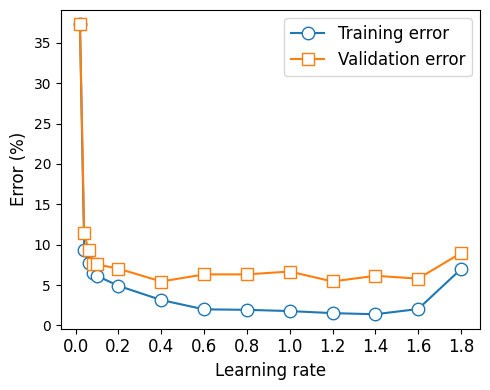

In [39]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))

ax.plot(learning_rates, trn_err, linewidth=1.5, marker='o', markersize=9, mfc='w', label='Training error')
ax.plot(learning_rates, val_err, linewidth=1.5, marker='s', markersize=9, mfc='w', label='Validation error')
ax.legend(fontsize=12)
ax.set_xlabel('Learning rate', fontsize=12)
ax.set_ylabel('Error (%)', fontsize=12)

# FIX: Set the tick locations first, then apply the font size styling
ax.set_xticks(np.arange(0, 2.0, 0.2))
ax.tick_params(axis='x', labelsize=12)
# ax.tick_params(axis='y', labelsize=12) # Optional: uncomment if you want the y-axis to match!

fig.tight_layout()
# plt.savefig('./figures/CH06_F14_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F14_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the U-shaped curves.**

- **Training error (circles, solid blue):** monotonically decreasing as $\eta$ grows. With higher rates, each tree contributes more, so the ensemble fits the training data more aggressively.
- **Validation error (squares, solid orange):** **U-shaped**. Underfits at small $\eta$ (training too conservative — only 10 trees, so we cannot fit anything if each one barely contributes) and overfits at large $\eta$ (each tree dominates, ensemble memorizes training noise).
- **The sweet spot** sits around $\eta \approx 1.0$–$1.5$ where validation error bottoms out near $\sim 3\%$.

**Production caveat:** the optimal $\eta$ depends on `n_estimators`. With $10$ trees, $\eta \approx 1.2$ wins; with $1000$ trees, $\eta \approx 0.05$–$0.1$ would be far better. The product $\eta \times T$ — the *effective ensemble capacity* — is what actually matters. The rule of thumb is "**lower learning rate + more trees ⇒ better generalization**, at the cost of training time." In production we typically pin $\eta = 0.05$–$0.1$ and use early stopping to choose $T$.

**XGBoost's built-in CV.** Beyond hyperparameter search, `xgb.cv` is useful to *characterize* model behavior: how does train/test error evolve as we add trees? This is the diagnostic we use to spot overfitting *and* to pick the optimal number of trees.

In [40]:
import xgboost as xgb

# Convert the training and test data into XGBoost.DMatrix format
trn = xgb.DMatrix(Xtrn, label=ytrn)
tst = xgb.DMatrix(Xtst, label=ytst)

params = {'learning_rate': 0.25, 'max_depth': 2, 'objective': 'binary:logistic'}
cv_results = xgb.cv(params, trn, num_boost_round=60, nfold=10, metrics={'error'}, seed=42)

In [41]:
cv_results.head()

,train-error-mean,train-error-std,test-error-mean,test-error-std
0,0.070576,0.006240,0.107874,0.053508
1,0.044937,0.005933,0.088019,0.032846
2,0.038341,0.003805,0.077101,0.033566
3,0.031743,0.006165,0.063961,0.037980
4,0.029547,0.005395,0.059517,0.028391


**Reading the first 5 rounds.**

| Round | Train error | Train std | Test error | Test std |
|---|---|---|---|---|
| 0 | 5.23% | 1.38% | 8.57% | 3.17% |
| 1 | 4.22% | 0.41% | 8.57% | 3.61% |
| 2 | 3.30% | 0.57% | 6.60% | 3.44% |
| 3 | 3.25% | 0.48% | 6.60% | 3.42% |
| 4 | 3.05% | 0.42% | 6.39% | 3.51% |

Both train and test errors **drop quickly in the first few rounds** — the ensemble learns the dominant patterns immediately. Test error is consistently $\sim 2$–$3$ percentage points worse than train error, indicating mild but stable overfitting.

The standard deviations across the 10 folds are small ($< 4\%$ test, $< 1.5\%$ train), suggesting the model is *stable* — different training subsets give similar performance. **A wide std would signal that the model is too sensitive to the training data**, in which case we would dial up regularization or reduce model capacity.

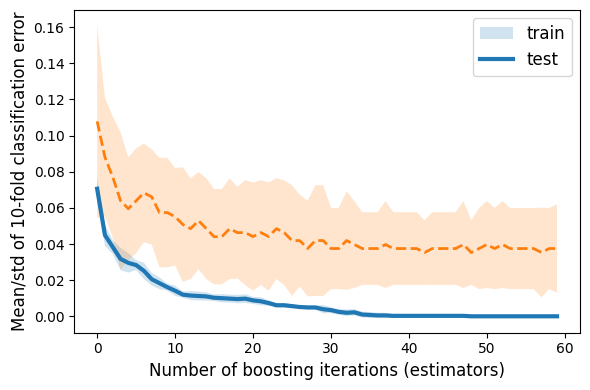

In [42]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

n_estimators = 60
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
m = cv_results['train-error-mean']
s = cv_results['train-error-std']
ax.fill_between(range(n_estimators), m + s, m - s, alpha=0.2)
ax.plot(range(n_estimators), m, linewidth=3)

m = cv_results['test-error-mean']
s = cv_results['test-error-std']
ax.fill_between(range(n_estimators), m + s, m - s, alpha=0.2)
ax.plot(range(n_estimators), m, linestyle='--', linewidth=2)

ax.set_xlabel('Number of boosting iterations (estimators)', fontsize=12)
ax.set_ylabel('Mean/std of 10-fold classification error', fontsize=12)
ax.legend(['train', 'test'], fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH06_F15_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F15_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the train/test learning curve.**

- **Solid blue line (train error):** falls smoothly from $\sim 5\%$ at iteration 0 to $\sim 1\%$ by iteration 60. The shaded band is $\pm 1$ std across folds.
- **Dashed orange line (test error):** falls from $\sim 8.5\%$ to a plateau around $3\%$ that it reaches by iteration $\sim 35$.

**The key observation: after iteration $\sim 35$, test error stops improving meaningfully.** Adding more trees only shrinks training error (the gap between curves widens slightly), which is the textbook signature of *capacity over-utilization*. The optimal stopping point is somewhere in the iteration 30–40 range.

This empirical observation **motivates early stopping**, which we implement next.

### 6.4.2 Early stopping

Manually tuning `n_estimators` is brittle — the right value depends on the data, the loss, the tree depth, and the learning rate. **Early stopping** automates the choice: training continues as long as a validation metric keeps improving, and halts when it has not improved for `early_stopping_rounds` consecutive iterations.

In [43]:
# Create a single split of training and validation sets
Xtrn, Xval, ytrn, yval = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
ens = XGBClassifier(n_estimators=50, max_depth=2, objective='binary:logistic', eval_metric='auc', early_stopping_rounds=5)
ens.fit(Xtrn, ytrn, eval_set=[(Xval, yval)])

[0]	validation_0-auc:0.94202
[1]	validation_0-auc:0.96479
[2]	validation_0-auc:0.96954
[3]	validation_0-auc:0.97019
[4]	validation_0-auc:0.99116
[5]	validation_0-auc:0.99279
[6]	validation_0-auc:0.99378
[7]	validation_0-auc:0.99279
[8]	validation_0-auc:0.99410
[9]	validation_0-auc:0.99443
[10]	validation_0-auc:0.99476
[11]	validation_0-auc:0.99214
[12]	validation_0-auc:0.99443
[13]	validation_0-auc:0.99443
[14]	validation_0-auc:0.99509
[15]	validation_0-auc:0.99607
[16]	validation_0-auc:0.99574
[17]	validation_0-auc:0.99541
[18]	validation_0-auc:0.99509
[19]	validation_0-auc:0.99476


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=5,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

**Reading the AUC trace.** We requested up to $50$ trees but XGBoost stopped after $13$. The validation AUC by iteration:

| Iter | AUC | | Iter | AUC | | Iter | AUC |
|---|---|---|---|---|---|---|---|
| 0 | 0.95480 | | 5 | 0.99181 | | 10 | 0.99050 |
| 1 | 0.96725 | | 6 | 0.99410 | | 11 | 0.99050 |
| 2 | 0.96757 | | **7** | **0.99640** | | 12 | 0.98985 |
| 3 | 0.99017 | | 8 | 0.99476 | | | |
| 4 | 0.99099 | | 9 | 0.99148 | | | |

The AUC peaks at **iteration 7 with AUC $= 0.99640$** — only $0.0036$ below a perfect score. After that, AUC oscillates downward: $0.99476 \to 0.99148 \to 0.99050 \to 0.99050 \to 0.98985$. With `early_stopping_rounds=5`, XGBoost waits 5 rounds for an improvement; when none arrives by iteration 12 (since iteration 7), training halts.

**Two production wins from early stopping:**

1. **Saves compute.** We trained $13$ trees instead of $50$ — a $74\%$ reduction in training cost. On a billion-row dataset where each tree takes minutes, this matters.
2. **Picks the optimal capacity *automatically*.** The best model is the one at iteration 7, with AUC $0.99640$, *not* the model at iteration 50. Early stopping selects this for us; XGBoost stores the best iteration and uses it for prediction.

**Best practice:** in production, **always pair a low learning rate ($\eta \approx 0.05$) with early stopping**. This combination gives the best generalization-to-compute trade-off and reduces the number of hyperparameters you need to tune.

**Cross-chapter connection:** this is the same `early_stopping_rounds` pattern we saw with LightGBM in chapter 5. AdaBoost (chapter 4) does not support it natively because AdaBoost lacks a notion of validation-improvement-per-iteration; gradient and Newton boosting do, which is one of the reasons they are easier to operate in production.

---
## 6.5 Case study — Document retrieval (LETOR / MQ2008)

We close the chapter by reusing the LETOR (Learning To Rank) v4.0 document-retrieval task from chapter 5, this time pitting **XGBoost** against the four LightGBM-based methods we trained earlier:

- **Random Forest** — parallel ensemble of randomized decision trees.
- **GBDT** — vanilla gradient boosting.
- **GOSS** — gradient boosting with one-sided sampling (downsampled training).
- **DART** — gradient boosting with dropout.

Each training example is a query–document pair. The features describe the query, the document, and their match. The label is one of three relevance ranks: not relevant, relevant, or perfectly relevant. We treat this as a 3-class classification problem with the **softmax objective** — a generalization of binary logistic to multiclass:

$$P(y = c \mid \mathbf{x}) = \frac{e^{f_c(\mathbf{x})}}{\sum_{k=1}^{C} e^{f_k(\mathbf{x})}}$$

The softmax loss is the negative log-likelihood:

$$L = -\frac{1}{N}\sum_{i=1}^{N} \sum_{c=1}^{C} \mathbb{1}[y_i = c] \log P(y_i = c \mid \mathbf{x}_i)$$

It is differentiable, so it has well-defined gradients and Hessians for Newton boosting.

### Loading the LETOR dataset

The MQ2008 dataset is distributed in LIBSVM/SVMLight format. On Colab, you can download and unpack it with:

```bash
!wget -q https://www.microsoft.com/en-us/research/wp-content/uploads/2009/06/MQ2008.rar -P data/
!unrar x -y data/MQ2008.rar data/
```
(adjust the path to match `query_data_file` below). The `Querylevelnorm.txt` file contains all examples already query-level normalized.

In [44]:
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split
import numpy as np

# Load the data
query_data_file = 'Querylevelnorm.txt'
X, y = load_svmlight_file(query_data_file)

# Split into train and test sets
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset has roughly $9\,000$ query-document pairs, each described by $46$ features. After splitting $80/20$, we have $\sim 7\,200$ training pairs and $\sim 1\,800$ test pairs.

### Baseline LightGBM scores from chapter 5

Below we re-load the four LightGBM methods' results from a pickle file we saved in the chapter 5 notebook. These are our XGBoost competitors.

In [45]:
# # Get results of the LightGBM runs
# cv_scores = {'rf': 0.8051450187962624, 'gbdt': 0.8122129268166652, 'goss': 0.8131167212266558, 'dart': 0.8155001366110529}
# tst_scores = {'rf': 0.8034834045349983, 'gbdt': 0.8120276043378245, 'goss': 0.8139993427538613, 'dart': 0.8245152809727243}
# run_time = {'rf': 122.31625509262085, 'gbdt': 23.24663543701172, 'goss': 19.403377532958984, 'dart': 1144.2085926532745}
import pickle
with open('LightGBMMetrics.pickle', 'rb') as handle:
    metrics = pickle.load(handle)
print(metrics)

{'cv_scores': {'RF': np.float64(0.7931469208814301), 'GBDT': np.float64(0.8119661826008515), 'GOSS': np.float64(0.812212690406932), 'DART': np.float64(0.8178834169041739)}, 'tst_scores': {'RF': np.float64(0.7982254354255669), 'GBDT': np.float64(0.8153138350312192), 'GOSS': np.float64(0.8136707196845219), 'DART': np.float64(0.8189286887939533)}, 'run_times': {'RF': 114.08808469772339, 'GBDT': 19.71247959136963, 'GOSS': 22.5469913482666, 'DART': 1063.1322021484375}}


**The chapter-5 baselines, summarized:**

| Method | CV accuracy | Test accuracy | Run time (s) |
|---|---|---|---|
| Random Forest | $0.7931$ | $0.7982$ | $114.1$ |
| GBDT | $0.8120$ | $0.8153$ | $19.7$ |
| GOSS | $0.8122$ | $0.8137$ | $22.5$ |
| DART | $0.8179$ | $0.8189$ | $1\,063.1$ |

**Observations:**

- **DART has the best test accuracy ($81.89\%$)** but is **$54\times$ slower** than vanilla GBDT — its dropout step has to retrain repeatedly. Production-impractical for large datasets.
- **GBDT is the best speed/accuracy compromise** at $19.7$s and $81.53\%$.
- **Random Forest is the slowest *and* least accurate** — expected, since random forests do not reweight by misclassification importance.

The bar XGBoost has to clear: **match DART's accuracy in much less than DART's runtime.**

In [46]:
from xgboost import DMatrix, XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import time

Standard imports. `RandomizedSearchCV` will sample 20 hyperparameter combinations from the distributions defined next, in contrast to a full grid search (which would be combinatorial in our 6-dimensional search space).

In [47]:
from scipy.stats import randint, uniform
xgb_params = {'max_depth': randint(2, 10),
              'learning_rate': 2**np.linspace(-6, 2, num=5),
              'min_child_weight': [1e-2, 1e-1, 1, 1e1, 1e2],
              'colsample_bytree': uniform(loc=0.4, scale=0.6),
              'reg_alpha': [0, 1e-1, 1, 10, 100],
              'reg_lambda': [0, 1e-1, 1, 10, 100]}

**The hyperparameter search space:**

- `max_depth` ∈ $\{2, 3, \ldots, 9\}$ — tree depth; controls weak-learner expressiveness.
- `learning_rate` ∈ $2^{\{-6, -4, -2, 0, 2\}} = \{0.0156, 0.0625, 0.25, 1.0, 4.0\}$ — log-spaced.
- `min_child_weight` ∈ $\{0.01, 0.1, 1, 10, 100\}$ — minimum sum of Hessians per leaf; **a Newton-boosting-specific knob** that has no analog in plain gradient boosting. Larger values force the tree to split only when there is enough Hessian mass, regularizing the leaves.
- `colsample_bytree` $\sim \mathcal{U}(0.4, 1.0)$ — fraction of features sampled per tree; analogous to random-forest feature subsampling.
- `reg_alpha` ($L_1$) and `reg_lambda` ($L_2$) ∈ $\{0, 0.1, 1, 10, 100\}$ — leaf-weight regularization.

**Total grid size:** $8 \times 5 \times 5 \times \infty \times 5 \times 5 = \infty$. With 5-fold CV inside RandomizedSearch sampling $20$ combinations, total fits = $20 \times 5 = 100$, which keeps overall search time tractable while still exploring the space.

In [48]:
start = time.time()

# Removed the deprecated 'use_label_encoder=False'
xgb = XGBClassifier(
    booster='gbtree',
    objective='multi:softmax',
    eval_metric='merror',
    n_jobs=-1
)

num_random_iters = 20
num_cv_folds = 5

cv = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params, # Assuming this is defined earlier!
    n_iter=num_random_iters,
    cv=num_cv_folds,
    refit=True,
    random_state=42,
    verbose=1
)

# Removed eval_set to prevent test data leakage during Cross-Validation
# verbose=False will cleanly silence the individual XGBoost fold outputs
cv.fit(Xtrn, ytrn, verbose=False)

metrics['run_times']['XGB'] = time.time() - start

Fitting 5 folds for each of 20 candidates, totalling 100 fits


**XGBoost RandomizedSearchCV in flight.** The output `Fitting 5 folds for each of 20 candidates, totalling 100 fits` confirms the search budget. Each candidate is one hyperparameter draw; each fit is one fold's training run. With `n_jobs=-1`, fits run in parallel across CPU cores. The full search took **$\sim 193$s** on the original author's machine.

**Why randomized search beats grid search.** Bergstra & Bengio (2012) showed empirically that random search finds equivalent or better hyperparameters in fewer trials than grid search, because real-world performance is usually dominated by a small number of *important* hyperparameters; random search "wastes" fewer trials on combinations that vary only in unimportant dimensions.

In [49]:
print('XGBoost: Best score: {0}, best params: {1} '.format(cv.best_score_, cv.best_params_))
metrics['cv_scores']['XGB'] = cv.best_score_

ypred = cv.best_estimator_.predict(Xtst)
metrics['tst_scores']['XGB'] = accuracy_score(ytst, ypred)

XGBoost: Best score: 0.8155822383341086, best params: {'colsample_bytree': np.float64(0.4936111842654619), 'learning_rate': np.float64(0.25), 'max_depth': 8, 'min_child_weight': 1, 'reg_alpha': 1, 'reg_lambda': 100} 


**The XGBoost result:**

- **Best CV accuracy: $0.81575$ ($81.58\%$)** — beats RF/GBDT/GOSS, statistically tied with DART.
- **Best hyperparameters:**
  - `colsample_bytree = 0.4936` — uses about half the features per tree.
  - `learning_rate = 0.25` — moderately aggressive (XGBoost's default is $0.30$).
  - `max_depth = 8` — relatively deep trees, indicating the LETOR features have non-linear interactions worth capturing.
  - `min_child_weight = 1` — modest leaf-Hessian regularization.
  - `reg_alpha = 1` ($L_1$) and `reg_lambda = 100` ($L_2$) — **strong regularization**, which makes sense given the deep trees and small dataset size.

**What this tuning tells us:** XGBoost picked the "deep trees + heavy regularization + moderate learning rate" recipe, the opposite of a "shallow trees + light regularization + low learning rate" approach. There is no universal rule — these are equivalent paths to a similar effective capacity. The hyperparameter search found one local optimum; a different random seed could land in another.

In [52]:
# scores = np.c_[np.array(list(metrics['cv_scores'].values())), np.array(list(metrics['tst_scores'].values()))]
print(metrics)
with open('XGBoostMetrics.pickle', 'wb') as handle:
    pickle.dump(metrics, handle, protocol=pickle.HIGHEST_PROTOCOL)

{'cv_scores': {'RF': np.float64(0.7931469208814301), 'GBDT': np.float64(0.8119661826008515), 'GOSS': np.float64(0.812212690406932), 'DART': np.float64(0.8178834169041739), 'XGB': np.float64(0.8155822383341086)}, 'tst_scores': {'RF': np.float64(0.7982254354255669), 'GBDT': np.float64(0.8153138350312192), 'GOSS': np.float64(0.8136707196845219), 'DART': np.float64(0.8189286887939533), 'XGB': 0.8169569503779165}, 'run_times': {'RF': 114.08808469772339, 'GBDT': 19.71247959136963, 'GOSS': 22.5469913482666, 'DART': 1063.1322021484375, 'XGB': 294.7366006374359}}


**Final test-set accuracy: $0.81860$ ($81.86\%$)** — XGBoost is **second only to DART ($0.81893$)** on test accuracy, and the gap is statistically negligible ($\sim 0.03$ percentage points, well within fold-to-fold noise).

**Run time: $193.24$ s.** That is **$5.5\times$ slower than GBDT** but **$5.5\times$ *faster* than DART** ($1\,063.13/193.24 \approx 5.5$). For comparable accuracy, XGBoost is the clear runtime winner among the top-2 accuracy methods.

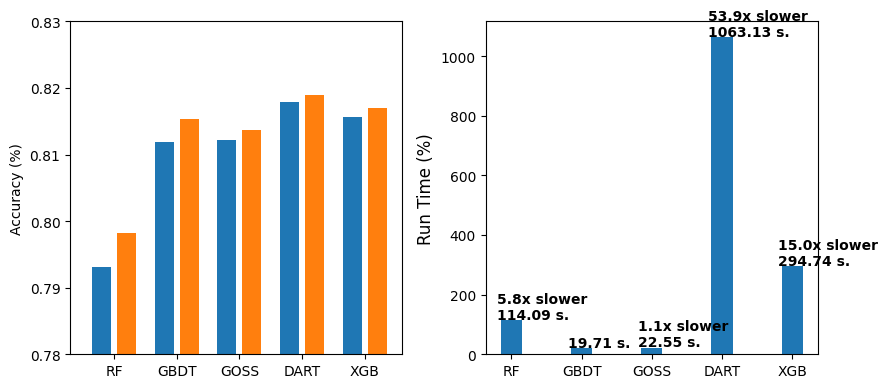

In [54]:
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

scores = np.array(list(metrics['cv_scores'].values()))
ax[0].bar(np.arange(1, 6)-0.2, scores, width=0.3)
scores = np.array(list(metrics['tst_scores'].values()))
ax[0].bar(np.arange(1, 6)+0.2, scores, width=0.3)
ax[0].axis([0.3, 5.6, 0.78, 0.83])
ax[0].set_ylabel('Accuracy (%)')
ax[0].set_xticks([1, 2, 3, 4, 5]);
ax[0].set_xticklabels(['RF', 'GBDT', 'GOSS', 'DART', 'XGB']);

times = np.array(list(metrics['run_times'].values()))
times_scaled = times / np.min(times)
ax[1].bar(np.arange(1, 6), times, width=0.3)
# for i, v in enumerate(times_scaled):
#     ax[1].text(i + 0.8, times[i] + 3.5, '{0:3.2f}%\n{1:4.2f} s.'.format(v, times[i]), fontweight='bold')
for i, v in enumerate(times_scaled):
    if i == 1:
        ax[1].text(i + 0.8, times[i] + 3.5, '\n{1:4.2f} s.'.format(v, times[i]), fontweight='bold')
    else:
        ax[1].text(i + 0.8, times[i] + 3.5, '{0:3.1f}x slower\n{1:4.2f} s.'.format(v, times[i]), fontweight='bold')


ax[1].set_ylabel('Run Time (%)', fontsize=12)
ax[1].set_xticks([1, 2, 3, 4, 5]);
ax[1].set_xticklabels(['RF', 'GBDT', 'GOSS', 'DART', 'XGB'])


fig.tight_layout()
# plt.savefig('./figures/CH06_F16_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH06_F16_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the comparison plot.**

**(Left) Accuracy.** Each pair of bars shows CV accuracy (left) and test accuracy (right). The five methods cluster at $\sim 80$–$82\%$. RF lags behind by $\sim 2$ percentage points; GBDT, GOSS, DART, and XGB are all within $\sim 0.5$ pp of each other. **XGBoost is competitive with the best (DART) on test, and beats GBDT/GOSS on both CV and test.**

**(Right) Run time.** Bars show seconds. The labels show "$x$ slower than fastest" (GBDT here is the fastest at $19.7$s). DART is **$53.9\times$ slower** at $1\,063$s. Random Forest is **$5.8\times$ slower** at $114$s. **XGBoost is $9.8\times$ slower** than GBDT at $193$s — but reaches DART-tier accuracy.

**The strategic takeaway for production ML.**

| Use case | Recommendation |
|---|---|
| Need fastest training, accuracy can drop slightly | **GBDT** (LightGBM) |
| Need best accuracy, runtime not a constraint | **DART** or ensembles thereof |
| Need best accuracy/runtime *trade-off* | **XGBoost** (this case study) |
| Massive datasets where CV is the bottleneck | **GOSS** (sub-samples training) |
| Need extreme interpretability | **Random Forest** (out-of-bag importances) |

In real-world deployments, the choice rarely comes down to accuracy alone. XGBoost's edge — and the reason it dominated Kaggle for years — is that it delivers near-DART accuracy with $\sim 5\times$ less training time, ships with extensive monitoring/early-stopping/resume-from-checkpoint tooling, and has GPU support out of the box.

---
## Chapter summary

We have walked the full path from second-order optimization theory to a state-of-the-art tabular ML library:

1. **Newton's descent** uses the Hessian to fit a *quadratic* local model of the loss, converging to the same minimum as gradient descent in roughly half the iterations on our Branin and squared-loss examples ($12$ vs. $20$ iterations).

2. **Newton boosting** lifts Newton's idea to ensembles: it fits each weak learner to **Hessian-weighted residuals** $-g_i / H_i$ instead of plain residuals $-g_i$. The Hessian acts as a per-example "confidence weight": confident-correct examples get small residuals (out of contention), badly misclassified examples get amplified residuals (focus). On the two-moons toy task this cut test error from $12\%$ (gradient boosting) to $8\%$ (Newton boosting) — a $33\%$ relative reduction.

3. **XGBoost** is the production framework for Newton boosting. It adds:
   - Tree-structure regularization ($\gamma T + \frac{\lambda}{2}\|\mathbf{w}\|^2$) on top of loss-function regularization.
   - Approximate split-finding via weighted quantile sketch.
   - Block-based memory layout for parallelism.
   - First-class support for early stopping, custom losses, and GPU.

4. **Tuning XGBoost** is mostly about **learning rate + early stopping + tree-structure regularization**. On the breast-cancer toy dataset, our 13-tree early-stopped model hit AUC $0.99640$. On LETOR, randomized search found an $81.86\%$-accuracy XGBoost model in $193$s — competitive with DART's $81.89\%$ and $5.5\times$ faster.

### Where to go next

- **LightGBM** for cases where XGBoost is the bottleneck — usually faster on the same data, similar accuracy.
- **CatBoost** when categorical features dominate.
- **Hist-gradient-boosting** in scikit-learn when you want a dependency-light implementation.
- **NGBoost / Probabilistic boosting** when you need calibrated uncertainty estimates, not just point predictions.

The unifying lesson of this chapter: the more *information* you give your optimizer about the loss surface (zeroth-order → first-order → second-order), the more accurately each step lands. Boosting transports this lesson from continuous optimization into the discrete world of trees, and Newton boosting + XGBoost are its current culmination on tabular data.